In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

abhilash437_md17_ethanol_path = kagglehub.dataset_download('abhilash437/md17-ethanol')
abhilash437_md17_aspirin_path = kagglehub.dataset_download('abhilash437/rmd17-aspirin')
abhilash437_md17_malonaldehyde_path = kagglehub.dataset_download('abhilash437/rmd17-malonaldehyde')
abhilash437_anchored_block_diagonal_koopman_model_pytorch_default_1_path = kagglehub.model_download('abhilash437/anchored-block-diagonal-koopman-model/PyTorch/default/1')
abhilash437_gru_baseline_pytorch_default_1_path = kagglehub.model_download('abhilash437/gru-baseline/PyTorch/default/1')

print('Data source import complete.')


100%|██████████| 60.7M/60.7M [00:00<00:00, 91.2MB/s]

Extracting files...


100%|██████████| 140M/140M [00:01<00:00, 85.5MB/s] 

Extracting files...


100%|██████████| 60.7M/60.7M [00:00<00:00, 101MB/s] 

Extracting files...


100%|██████████| 68.6k/68.6k [00:00<00:00, 1.85MB/s]


100%|██████████| 108k/108k [00:00<00:00, 1.62MB/s]

Data source import complete.


In [3]:
%pip install torch_geometric statsmodels -q

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
import torch_geometric as pyg
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_remaining_self_loops

import numpy as np
import scipy.sparse as sp
from scipy.stats import ttest_ind
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.metrics import roc_auc_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd

import torch.optim as optim

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

PROJECT_ROOT = "/kaggle/working/koopman_md17_project"
DIRS = {
    "data": os.path.join(PROJECT_ROOT, "data"),
    "checkpoints": os.path.join(PROJECT_ROOT, "checkpoints"),
    "results": os.path.join(PROJECT_ROOT, "results")
}

# Safely generate the directory tree
for dir_name, dir_path in DIRS.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"Directory established: {dir_path}")

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Random seed for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.8 MB/s eta 0:00:00a 0:00:01
Device: cpu
Directory established: /kaggle/working/koopman_md17_project/data
Directory established: /kaggle/working/koopman_md17_project/checkpoints
Directory established: /kaggle/working/koopman_md17_project/results
Device: cpu


In [4]:
"""
dataset_adapter
──────────────────
Base interface and MD17 adapter for the Koopman dynamics framework.

Usage
-----
adapter = MD17Adapter(path="/kaggle/working/.../md17_ethanol.npz",
                      molecule="ethanol",
                      sub_sampling=2,
                      window_len=150,
                      train_frac=0.8)

train_split, test_split = adapter.load()

# train_split.X      : np.ndarray  (N_train, T-1, D*2)
# train_split.y      : np.ndarray  (N_train,)   int labels
# train_split.lengths: List[int]   true lengths before padding
# train_split.meta   : dict        logging / plot titles
"""

from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Tuple, List

import numpy as np


# ─────────────────────────────────────────────────────────────────────────────
# 1. Standard data container
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class DatasetSplit:
    """
    Standard container produced by every adapter.

    Fields
    ------
    X       np.ndarray  shape (N, T, D)
                N = number of trajectory windows
                T = max sequence length across the split (shorter ones padded
                    with zeros to this length)
                D = feature dimension per timestep

    y       np.ndarray  shape (N,)  int64
                Class label per trajectory.
                If the dataset has no meaningful labels, this is all zeros.

    lengths List[int]   length N
                True (unpadded) length of each trajectory.
                The model uses these to ignore the zero-padded tail.

    meta    dict
                Dataset-specific metadata for logging and plot titles.
                Guaranteed keys: 'dataset', 'molecule', 'D', 'split'
    """
    X      : np.ndarray
    y      : np.ndarray
    lengths: List[int]
    meta   : dict = field(default_factory=dict)


# ─────────────────────────────────────────────────────────────────────────────
# 2. Abstract base class — every new dataset subclasses this
# ─────────────────────────────────────────────────────────────────────────────

class DynamicsDatasetAdapter(ABC):
    """
    Contract all dataset adapters must satisfy.

    The training loop and evaluator only call:
        train_split, test_split = adapter.load()
        model = SomeModel(input_dim=adapter.input_dim, ...)

    They never touch raw files, windowing logic, or label encodings.
    """

    @abstractmethod
    def load(self) -> Tuple[DatasetSplit, DatasetSplit]:
        """
        Parse raw data, compute features, window, pad, split.
        Returns (train_split, test_split).
        """
        pass

    @property
    @abstractmethod
    def input_dim(self) -> int:
        """
        Feature dimension D seen by the model.

        Must be computable BEFORE load() is called so the model can be
        instantiated before loading data into memory.
        """
        pass

    @property
    @abstractmethod
    def name(self) -> str:
        """Human-readable dataset name used in log lines and plot titles."""
        pass

In [ ]:
# ── Phase 1: Cell 1 - GraphDatasetSplit ──────────────────────────────────────
from dataclasses import dataclass, field
import numpy as np
import torch
from typing import List

@dataclass
class GraphDatasetSplit:
    """
    Data split container for molecular graphs.

    Fields
    ------
    node_features : np.ndarray  shape (N, T, n_atoms, 6)
                    Positions [x, y, z] concatenated with finite-difference
                    velocities [vx, vy, vz].
    edge_index    : torch.Tensor shape (2, n_edges)
                    Long tensor representing the fixed molecular graph.
    edge_features : np.ndarray  shape (N, T, n_edges, 1)
                    Evolving bond distances for each edge in edge_index.
    y             : np.ndarray  shape (N,)
                    Median-split energy classification labels (retained for signature).
    lengths       : List[int]   length N
                    True (unpadded) sequence lengths.
    meta          : dict
                    Logging and visualization metadata.
    """
    node_features: np.ndarray
    edge_index: torch.Tensor
    edge_features: np.ndarray
    y: np.ndarray
    lengths: List[int]
    meta: dict = field(default_factory=dict)


In [6]:
# ── Phase 1: Cell 2 (Updated with Chronological Sorting & Window Alignment) ──
from typing import Tuple
import numpy as np
import torch

class MD17AdapterV2(DynamicsDatasetAdapter):
    """
    Graph-based adapter for the MD17 molecular dynamics benchmark.
    Aligns molecular frames to their principal axes of inertia to ensure
    translational and rotational invariance.
    """
    _ATOM_COUNTS = {
        "aspirin"      : 21,
        "benzene"      : 12,
        "ethanol"      :  9,
        "malonaldehyde": 9,
        "naphthalene"  : 18,
        "salicylic"    : 16,
        "toluene"      : 15,
        "uracil"       : 12,
    }

    def __init__(
        self,
        path: str,
        molecule: str = "ethanol",
        sub_sampling: int = 2,
        window_len: int = 150,
        train_frac: float = 0.8,
        bond_cutoff: float = 1.6,
    ):
        self.path         = path
        self.molecule     = molecule.lower()
        self.sub_sampling = sub_sampling
        self.window_len   = window_len
        self.train_frac   = train_frac
        self.bond_cutoff  = bond_cutoff

        # Resolve atom counts
        if self.molecule in self._ATOM_COUNTS:
            self._n_atoms = self._ATOM_COUNTS[self.molecule]
        else:
            self._n_atoms = None

    @property
    def name(self) -> str:
        return f"MD17-{self.molecule}-Graph"

    @property
    def input_dim(self) -> int:
        return 6  # [x, y, z, vx, vy, vz]

    def load(self) -> Tuple[GraphDatasetSplit, GraphDatasetSplit]:
        # 1. Read raw file
        raw = np.load(self.path, allow_pickle=True)
        coords = raw["coords"] if "coords" in raw else raw["R"]
        energies = raw["energies"] if "energies" in raw else raw["E"]

        # [CRITICAL FIX 1] Sort chronologically by old_indices (rMD17 is shuffled by default)
        if "old_indices" in raw:
            sorted_idx = np.argsort(raw["old_indices"])
            coords = coords[sorted_idx]
            energies = energies[sorted_idx]

        if "nuclear_charges" in raw:
            self._n_atoms = int(raw["nuclear_charges"].shape[0])

        n_frames, n_atoms, _ = coords.shape
        if self._n_atoms is None:
            self._n_atoms = n_atoms

        # 2. Sub-sample frames
        coords   = coords[::self.sub_sampling]
        energies = energies[::self.sub_sampling]

        # 3. Dynamic Bond Detection (on first frame before centering)
        diff0 = coords[0, :, None, :] - coords[0, None, :, :]
        dist0 = np.sqrt(np.sum(diff0 ** 2, axis=-1))
        adj = dist0 < self.bond_cutoff
        np.fill_diagonal(adj, False)
        src, dst = np.where(adj)
        edge_index = torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)

        # 4. Partition sub-sampled trajectory into windows
        coord_windows, labels = self._make_coordinate_windows(coords, energies)

        # 5. Split train / test
        split_idx = int(len(coord_windows) * self.train_frac)
        train_coords = coord_windows[:split_idx]
        train_labels = labels[:split_idx]
        test_coords  = coord_windows[split_idx:]
        test_labels  = labels[split_idx:]

        # 6. Apply centering/alignment and finite-difference velocities
        train_split = self._build_graph_split(train_coords, train_labels, edge_index, split="train")
        test_split  = self._build_graph_split(test_coords,  test_labels,  edge_index, split="test")

        return train_split, test_split

    def _make_coordinate_windows(self, coords, energies):
        total_steps = coords.shape[0]
        n_windows   = (total_steps - self.window_len) // self.window_len

        threshold     = np.median(energies)
        coord_windows = []
        labels        = []

        for idx in range(n_windows):
            start = idx * self.window_len
            end   = start + self.window_len
            coord_windows.append(coords[start:end])
            mean_energy = np.mean(energies[start:end])
            labels.append(1 if mean_energy > threshold else 0)

        return coord_windows, labels

    def _build_graph_split(self, coord_windows, labels, edge_index, split):
        node_feats_list = []
        edge_feats_list = []
        true_lengths    = []

        src, dst = edge_index.numpy()

        for win in coord_windows:
            # win shape: (window_len, n_atoms, 3)
            # [CRITICAL FIX 2] Align the ENTIRE window to the first frame's principal axes
            P0 = win[0]
            P0_centered = P0 - P0.mean(axis=0, keepdims=True)
            C0 = np.dot(P0_centered.T, P0_centered)
            U0, _, _ = np.linalg.svd(C0)

            # Resolve principal axis sign flip ambiguity using the first frame
            proj_first = np.dot(P0_centered[0], U0)
            for col in range(3):
                if proj_first[col] < 0:
                    U0[:, col] *= -1

            win_aligned = []
            for t in range(win.shape[0]):
                P = win[t]  # (n_atoms, 3)
                P_centered = P - P.mean(axis=0, keepdims=True)
                win_aligned.append(np.dot(P_centered, U0))

            win_aligned = np.array(win_aligned)  # (window_len, n_atoms, 3)

            pos = win_aligned[1:]                                    # (window_len - 1, n_atoms, 3)
            vel = win_aligned[1:] - win_aligned[:-1]                 # (window_len - 1, n_atoms, 3)
            node_feat = np.concatenate([pos, vel], axis=-1)          # (window_len - 1, n_atoms, 6)
            node_feats_list.append(node_feat)

            # Compute evolving edge distances over rollout time
            diff = pos[:, src] - pos[:, dst]
            edge_dist = np.sqrt(np.sum(diff ** 2, axis=-1, keepdims=True))
            edge_feats_list.append(edge_dist)

            true_lengths.append(pos.shape[0])

        max_len   = max(true_lengths)
        n_windows = len(coord_windows)
        n_edges   = edge_index.shape[1]

        node_features_padded = np.zeros((n_windows, max_len, self._n_atoms, 6), dtype=np.float32)
        edge_features_padded = np.zeros((n_windows, max_len, n_edges, 1), dtype=np.float32)

        for i in range(n_windows):
            node_features_padded[i, :true_lengths[i]] = node_feats_list[i]
            edge_features_padded[i, :true_lengths[i]] = edge_feats_list[i]

        y = np.array(labels, dtype=np.int64)

        meta = {
            "dataset": "MD17",
            "molecule": self.molecule,
            "D": 6,
            "n_atoms": self._n_atoms,
            "n_edges": n_edges,
            "window_len": self.window_len,
            "sub_sampling": self.sub_sampling,
            "split": split,
            "n_trajectories": n_windows,
        }

        return GraphDatasetSplit(
            node_features = node_features_padded,
            edge_features = edge_features_padded,
            edge_index    = edge_index,
            y             = y,
            lengths       = true_lengths,
            meta          = meta,
        )


In [7]:
# ── Phase 1: Cell 3 - Verification Script ─────────────────────────────────────
import os

# 1. Instantiate the new graph adapter for Ethanol
graph_adapter = MD17AdapterV2(
    path         = os.path.join(abhilash437_md17_ethanol_path, 'rmd17_ethanol.npz'),
    molecule     = "ethanol",
    sub_sampling = 2,
    window_len   = 150,
    train_frac   = 0.8,
)

# 2. Load the splits
print("Loading molecular graph splits...")
graph_train_split, graph_test_split = graph_adapter.load()

# 3. Print verification info
print("\n" + "=" * 50)
print("VERIFICATION RESULTS")
print("=" * 50)
print(f"Node features shape (N, T, n_atoms, 6): {graph_train_split.node_features.shape}")
print(f"Edge features shape (N, T, n_edges, 1): {graph_train_split.edge_features.shape}")
print(f"Edge index shape (2, n_edges)         : {graph_train_split.edge_index.shape}")
print(f"Number of edges detected              : {graph_train_split.edge_index.shape[1]}")
print(f"Metadata                              : {graph_train_split.meta}")

# 4. Check that connectivity makes sense (directed bonds for C2H6O)
# Ethanol has 9 atoms and 8 chemical bonds. Directed graph representation should have 16 edges.
n_edges = graph_train_split.edge_index.shape[1]
if n_edges == 16:
    print("\nSUCCESS: Successfully detected exactly 16 directed edges (representing 8 chemical bonds) for Ethanol!")
else:
    print(f"\nWARNING: Unexpected number of edges detected ({n_edges}). Check threshold/coordinates.")
print("=" * 50)


Loading molecular graph splits...

VERIFICATION RESULTS
Node features shape (N, T, n_atoms, 6): (265, 149, 9, 6)
Edge features shape (N, T, n_edges, 1): (265, 149, 16, 1)
Edge index shape (2, n_edges)         : torch.Size([2, 16])
Number of edges detected              : 16
Metadata                              : {'dataset': 'MD17', 'molecule': 'ethanol', 'D': 6, 'n_atoms': 9, 'n_edges': 16, 'window_len': 150, 'sub_sampling': 2, 'split': 'train', 'n_trajectories': 265}

SUCCESS: Successfully detected exactly 16 directed edges (representing 8 chemical bonds) for Ethanol!


In [ ]:
# ── Phase 2: Cell 1 - EdgeConditionedConv ────────────────────────────────────
import torch
import torch.nn as nn
from torch_geometric.nn import MessagePassing

class EdgeConditionedConv(MessagePassing):
    """
    Message passing layer incorporating edge features (bond distances).
    Computes message: m_ij = MLP([h_i, h_j, e_ij])
    """
    def __init__(self, in_channels: int, edge_channels: int, out_channels: int):
        super().__init__(aggr='mean')
        self.mlp = nn.Sequential(
            nn.Linear(in_channels * 2 + edge_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels)
        )
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)
    def message(self, x_i: torch.Tensor, x_j: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        tmp = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return self.mlp(tmp)


In [ ]:
# ── Phase 2: Cell 2 - GraphEncoder ───────────────────────────────────────────
import torch.nn.functional as F

class GraphEncoder(nn.Module):
    """
    Encoder that outputs a flattened graph-state vector of node embeddings
    without any global pooling: (B, T, n_atoms, node_dim) → (B, T, n_atoms * hidden_dim).
    """
    def __init__(self, node_dim: int = 6, edge_dim: int = 1, hidden_dim: int = 64):
        super().__init__()
        self.node_project = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim)
        )
        self.conv1 = EdgeConditionedConv(in_channels=hidden_dim, edge_channels=edge_dim, out_channels=hidden_dim)
        self.conv2 = EdgeConditionedConv(in_channels=hidden_dim, edge_channels=edge_dim, out_channels=hidden_dim)
    def forward(self, node_features: torch.Tensor, edge_index: torch.Tensor, edge_features: torch.Tensor) -> torch.Tensor:
        B, T, n_atoms, _ = node_features.shape
        n_edges = edge_index.shape[1]

        # Flatten time and batch dimensions for GNN processing
        x = node_features.reshape(B * T * n_atoms, -1)
        edge_attr = edge_features.reshape(B * T * n_edges, -1)
        device = node_features.device
        # Compute batch offset indexes for the graph structure
        offsets = torch.arange(B * T, device=device).view(B * T, 1, 1) * n_atoms
        edge_index_batched = edge_index.unsqueeze(0).to(device) + offsets
        edge_index_batched = edge_index_batched.transpose(0, 1).reshape(2, -1)
        # Message passing
        h = self.node_project(x)
        h = self.conv1(h, edge_index_batched, edge_attr)
        h = F.gelu(h)
        h = self.conv2(h, edge_index_batched, edge_attr) # Shape: (B * T * n_atoms, hidden_dim)
        # Flatten node dimensions to produce the graph-state vector
        h_seq = h.view(B, T, n_atoms, h.shape[-1]) # Shape: (B, T, 576)
        return h_seq

In [ ]:
# ── Phase 4: Cell 1 - GraphDecoder ────────────────────────────────────────────
import torch
import torch.nn as nn

class GraphDecoder(nn.Module):
    """
    Decoder mapping the flattened graph state vector back to coordinates: R^576 → R^{n_atoms x 3}.
    """
    def __init__(self, state_dim: int = 576, hidden_dim: int = 128, n_atoms: int = 9):
        super().__init__()
        self.n_atoms = n_atoms
        self.mlp = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, n_atoms * 3)
        )
    def forward(self, s: torch.Tensor) -> torch.Tensor:
        if s.dim() == 2:
            B, D = s.shape
            out = self.mlp(s)
            return out.view(B, self.n_atoms, 3)
        else:
            B, T, D = s.shape
            out = self.mlp(s)
            return out.view(B, T, self.n_atoms, 3)
print("Phase 5 Dataset split and GNN layers defined.")


Phase 5 Dataset split and GNN layers defined.


In [ ]:
# ── Phase 6: Cell 2 - Node-Level Models ──────────────────────────────────────
class GraphKoopmanNet(nn.Module):
    """
    Koopman dynamics model operating directly on GNN node embeddings.
    """
    def __init__(self, node_dim: int = 6, edge_dim: int = 1, hidden_dim: int = 64, latent_dim: int = 576, n_atoms: int = 9):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.n_atoms = n_atoms
        self.encoder = GraphEncoder(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=hidden_dim)
        self.decoder = GraphDecoder(state_dim=latent_dim, hidden_dim=128, n_atoms=n_atoms)
        self.A_raw = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.02)

    @property
    def K(self):
        A_skew = self.A_raw - self.A_raw.T
        return torch.matrix_exp(A_skew)

    def forward(self, node_features, edge_index, edge_features, lengths):
        return self.encoder(node_features, edge_index, edge_features)

    def forward_rollout(self, h0, steps=100, latent_seed=True):
        if latent_seed:
            h = h0[:, 0]  # (B, n_atoms, hidden_dim)
        else:
            raise NotImplementedError()
        K = self.K
        rollout = []
        h_init = h
        for t in range(steps):
            K_pow = torch.matrix_power(K, t)
            rollout.append(torch.matmul(h_init, K_pow.t()))
        return torch.stack(rollout, dim=1)

    def post_step_hook(self):
        pass


class GraphGRUNet(nn.Module):
    """
    GRU dynamics baseline operating directly on GNN node embeddings.
    """
    def __init__(self, node_dim: int = 6, edge_dim: int = 1, hidden_dim: int = 64, latent_dim: int = 576, n_atoms: int = 9):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.n_atoms = n_atoms
        self.encoder = GraphEncoder(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=hidden_dim)
        self.decoder = GraphDecoder(state_dim=latent_dim, hidden_dim=128, n_atoms=n_atoms)
        self.rnn_transition = nn.GRUCell(hidden_dim, hidden_dim)

    def forward(self, node_features, edge_index, edge_features, lengths):
        return self.encoder(node_features, edge_index, edge_features)

    def forward_rollout(self, h0, steps=100, latent_seed=True):
        if latent_seed:
            h = h0[:, 0]  # (B, n_atoms, hidden_dim)
        else:
            raise NotImplementedError()
        B, n_atoms, hidden_dim = h.shape
        rollout = [h]
        for _ in range(1, steps):
            h_flat = h.reshape(B * n_atoms, hidden_dim)
            h_next_flat = self.rnn_transition(h_flat, h_flat)
            h = h_next_flat.reshape(B, n_atoms, hidden_dim)
            rollout.append(h)
        return torch.stack(rollout, dim=1)

    def post_step_hook(self):
        pass

print("Graph-State dynamics models defined.")


Graph-State dynamics models defined.


In [ ]:
def graph_state_koopman_compute_loss(self, outputs, targets, lengths, epoch, node_features=None):
    h_seq = outputs  # (B, T, n_atoms, hidden_dim)
    K = self.K
    B, T, n_atoms, hidden_dim = h_seq.shape
    # 1. One-step transition loss
    h_t_list, h_tgt_list = [], []
    for b, L in enumerate(lengths):
        if L < 2: continue
        h_t_list.append(h_seq[b, :L-1])
        h_tgt_list.append(h_seq[b, 1:L])
    h_t = torch.cat(h_t_list, dim=0).reshape(-1, hidden_dim)
    h_tgt = torch.cat(h_tgt_list, dim=0).reshape(-1, hidden_dim)
    h_pred = torch.matmul(h_t, K.t())
    l_dyn = F.mse_loss(h_pred, h_tgt)
    # 2. Collapse prevention
    step_diff = torch.norm(h_tgt - h_t, dim=-1)
    step_norm = torch.norm(h_t, dim=-1) + 1e-8
    relative_change = (step_diff / step_norm).mean()
    l_collapse = torch.relu(0.05 - relative_change)
    # 3. Coordinate reconstruction loss (Option A: Global Decoder)
    if node_features is not None:
        coords_true = node_features[:, :, :, :3]
        s_seq = h_seq.reshape(B, T, n_atoms * hidden_dim)
        coords_pred = self.decoder(s_seq)
        l_recon = F.mse_loss(coords_pred, coords_true)
    else:
        l_recon = 0.0
    total_loss = l_dyn + 2.0 * l_collapse + 10.0 * l_recon
    return total_loss, {
        'loss': total_loss.item(),
        'l_dyn': l_dyn.item(),
        'l_collapse': l_collapse.item(),
        'l_recon': l_recon.item() if node_features is not None else 0.0
    }

def graph_state_gru_compute_loss(self, outputs, targets, lengths, epoch, node_features=None):
    h_seq = outputs
    B, T, n_atoms, hidden_dim = h_seq.shape
    h_t_list, h_tgt_list = [], []
    for b, L in enumerate(lengths):
        if L < 2: continue
        h_t_list.append(h_seq[b, :L-1])
        h_tgt_list.append(h_seq[b, 1:L])
    h_t = torch.cat(h_t_list, dim=0).reshape(-1, hidden_dim)
    h_tgt = torch.cat(h_tgt_list, dim=0).reshape(-1, hidden_dim)
    h_pred = self.rnn_transition(h_t, h_t)
    l_dyn = F.mse_loss(h_pred, h_tgt)
    step_diff = torch.norm(h_tgt - h_t, dim=-1)
    step_norm = torch.norm(h_t, dim=-1) + 1e-8
    relative_change = (step_diff / step_norm).mean()
    l_collapse = torch.relu(0.05 - relative_change)
    if node_features is not None:
        coords_true = node_features[:, :, :, :3]
        s_seq = h_seq.reshape(B, T, n_atoms * hidden_dim)
        coords_pred = self.decoder(s_seq)
        l_recon = F.mse_loss(coords_pred, coords_true)
    else:
        l_recon = 0.0
    total_loss = l_dyn + 2.0 * l_collapse + 10.0 * l_recon
    return total_loss, {
        'loss': total_loss.item(),
        'l_dyn': l_dyn.item(),
        'l_collapse': l_collapse.item(),
        'l_recon': l_recon.item() if node_features is not None else 0.0
    }

GraphKoopmanNet.compute_loss = graph_state_koopman_compute_loss
GraphGRUNet.compute_loss     = graph_state_gru_compute_loss
print("Phase 6 Loss functions defined.")


Phase 6 Loss functions defined.


In [13]:
# ── Phase 6: Cell 3 - GraphTrainer ───────────────────────────────────────────
import numpy as np
import os
import torch
from sklearn.metrics import r2_score

class GraphTrainer:
    """
    Trainer for Graph dynamics models (GraphKoopmanNet and GraphGRUNet).
    Guards checkpoints against trivial latent collapse.
    """
    def __init__(
        self,
        model,
        optimizer,
        checkpoint_dir,
        checkpoint_name="best.pt",
        epochs=100,
        batch_size=16,
        device="cpu",
        log_every=10,
    ):
        self.model           = model.to(device)
        self.optimizer       = optimizer
        self.checkpoint_dir  = checkpoint_dir
        self.checkpoint_name = checkpoint_name
        self.epochs          = epochs
        self.batch_size      = batch_size
        self.device          = device
        self.log_every       = log_every
        os.makedirs(checkpoint_dir, exist_ok=True)
    def fit(self, train_split: GraphDatasetSplit, val_split: GraphDatasetSplit):
        node_features_train = torch.tensor(train_split.node_features, dtype=torch.float32, device=self.device)
        edge_features_train = torch.tensor(train_split.edge_features, dtype=torch.float32, device=self.device)
        edge_index_train    = train_split.edge_index.to(self.device)
        train_lengths       = train_split.lengths
        node_features_val = torch.tensor(val_split.node_features, dtype=torch.float32, device=self.device)
        edge_features_val = torch.tensor(val_split.edge_features, dtype=torch.float32, device=self.device)
        edge_index_val    = val_split.edge_index.to(self.device)
        val_lengths       = val_split.lengths
        N = node_features_train.shape[0]
        best_r2   = -1e9
        best_info = {'epoch': -1, 'val_r2': -1e9}
        for epoch in range(1, self.epochs + 1):
            avg_log = self._train_epoch(
                node_features_train, edge_index_train, edge_features_train, train_lengths, N, epoch
            )
            val_r2 = self._compute_val_r2(
                node_features_val, edge_index_val, edge_features_val, val_lengths
            )
            # Save best checkpoint (ignoring collapsed epochs returning -1.0)
            if val_r2 > best_r2:
                best_r2 = val_r2
                best_info = {
                    'epoch':  epoch,
                    'val_r2': val_r2,
                }
                torch.save({
                    'epoch':            epoch,
                    'model_state_dict': self.model.state_dict(),
                    'val_r2':           val_r2,
                }, os.path.join(self.checkpoint_dir, self.checkpoint_name))
            if epoch % self.log_every == 0 or epoch == 1:
                print(
                    f"Epoch {epoch:>3d}/{self.epochs} | "
                    f"Loss {avg_log.get('loss', 0):.4f} | "
                    f"l_dyn {avg_log.get('l_dyn', 0):.4f} | "
                    f"l_recon {avg_log.get('l_recon', 0):.4f} | "
                    f"Val R\u00b2 {val_r2:.4f}  "
                    f"{'\u2190 BEST' if best_info.get('epoch') == epoch else ''}"
                )
        print(f"\nBest \u2192 epoch {best_info['epoch']}, Val R\u00b2 = {best_info['val_r2']:.4f}")
        return best_info
    def _train_epoch(self, node_feats, edge_idx, edge_feats, lengths, N, epoch):
        self.model.train()
        perm = torch.randperm(N)
        total_log   = {}
        num_batches = 0
        for start in range(0, N, self.batch_size):
            idx = perm[start : start + self.batch_size]
            batch_nodes = node_feats[idx]
            batch_edges = edge_feats[idx]
            batch_lens  = [lengths[i] for i in idx.tolist()]
            self.optimizer.zero_grad()
            h_seq = self.model(batch_nodes, edge_idx, batch_edges, batch_lens)
            loss, log = self.model.compute_loss(
                h_seq, targets=None, lengths=batch_lens, epoch=epoch, node_features=batch_nodes
            )
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            self.model.post_step_hook()
            for k, v in log.items():
                total_log[k] = total_log.get(k, 0.0) + v
            num_batches += 1
        return {k: v / num_batches for k, v in total_log.items()}
    @torch.no_grad()
    def _compute_val_r2(self, node_feats, edge_idx, edge_feats, val_lengths):
        self.model.eval()
        h_seq = self.model(node_feats, edge_idx, edge_feats, val_lengths)
        B, T, n_atoms, hidden_dim = h_seq.shape
        # Reject checkpoints if validation latent space collapsed
        all_ratios = []
        for b, L in enumerate(val_lengths):
            if L < 2: continue
            h_seq_b = h_seq[b, :L]
            h_seq_b_flat = h_seq_b.reshape(L, n_atoms * hidden_dim)
            diffs = (h_seq_b_flat[1:] - h_seq_b_flat[:-1]).norm(dim=1)
            norms = h_seq_b_flat[:-1].norm(dim=1) + 1e-8
            ratios = (diffs / norms).tolist()
            all_ratios.extend(ratios)

        mean_relative_change = np.mean(all_ratios) if all_ratios else 0.0
        if mean_relative_change < 0.05:
            return -1.0
        h_t_list, h_tgt_list = [], []
        for b, L in enumerate(val_lengths):
            if L < 2: continue
            h_t_list.append(h_seq[b, :L-1])
            h_tgt_list.append(h_seq[b, 1:L])
        h_t   = torch.cat(h_t_list,   dim=0).reshape(-1, hidden_dim)
        h_tgt = torch.cat(h_tgt_list, dim=0).reshape(-1, hidden_dim)
        if hasattr(self.model, 'K'):
            K_node = self.model.K
            h_pred = torch.matmul(h_t, K_node.t())
        else:
            h_pred = self.model.rnn_transition(h_t, h_t)
        y_true = h_tgt.cpu().numpy()
        y_pred = h_pred.cpu().numpy()
        r2 = r2_score(y_true.ravel(), y_pred.ravel())
        self.model.train()
        return r2
print("Phase 6 Trainer defined.")


Phase 6 Trainer defined.


In [14]:
# ── Phase 6: Cell 4 - Evaluator & Plotting ──────────────────────────────────
from typing import Optional
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

@dataclass
class GraphEvalResults:
    """
    Standard evaluation results container for graph state models.
    """
    koopman_mse_mean : np.ndarray
    koopman_mse_std  : np.ndarray
    baseline_mse_mean: np.ndarray
    baseline_mse_std : np.ndarray

    rho_koopman      : float

    koopman_geom_mean : np.ndarray
    koopman_geom_std  : np.ndarray
    baseline_geom_mean: np.ndarray
    baseline_geom_std : np.ndarray

    koopman_node_geom_mean : np.ndarray
    koopman_node_geom_std  : np.ndarray
    baseline_node_geom_mean: np.ndarray
    baseline_node_geom_std : np.ndarray

    relative_change_koopman : float
    relative_change_baseline: float

    meta: dict = field(default_factory=dict)


class GraphKoopmanEvaluator:
    """
    Evaluator for Graph dynamics models. Computes rollout MSE, spectral radius,
    and inter-atom geometry retention for both coordinate and node embedding spaces.
    """
    def __init__(
        self,
        koopman_model  : nn.Module,
        baseline_model : nn.Module,
        device         : str = 'cpu',
        rollout_steps  : int = 29,
        batch_size     : int = 64,
        n_atoms        : int = 9,
        hidden_dim     : int = 64
    ):
        self.koopman_model  = koopman_model.to(device).eval()
        self.baseline_model = baseline_model.to(device).eval()
        self.device         = device
        self.rollout_steps  = rollout_steps
        self.batch_size     = batch_size
        self.n_atoms        = n_atoms
        self.hidden_dim     = hidden_dim

    def run(self, split: GraphDatasetSplit) -> GraphEvalResults:
        node_feats = torch.tensor(split.node_features, dtype=torch.float32, device=self.device)
        edge_feats = torch.tensor(split.edge_features, dtype=torch.float32, device=self.device)
        edge_idx   = split.edge_index.to(self.device)
        lengths    = split.lengths

        with torch.no_grad():
            z_koop = self._encode_all(self.koopman_model, node_feats, edge_idx, edge_feats, lengths)
            z_base = self._encode_all(self.baseline_model, node_feats, edge_idx, edge_feats, lengths)

            koop_mse_mean, koop_mse_std = self._rollout_mse(self.koopman_model, z_koop, lengths)
            base_mse_mean, base_mse_std = self._rollout_mse(self.baseline_model, z_base, lengths)

            rho_koopman = self._spectral_radii(self.koopman_model)

            # Coordinate geometry retention (physical geometry ratio)
            koop_geom_mean, koop_geom_std = self._coordinate_geometry_retention(self.koopman_model, z_koop, lengths)
            base_geom_mean, base_geom_std = self._coordinate_geometry_retention(self.baseline_model, z_base, lengths)

            # Node embedding geometry retention (embedding geometry ratio)
            k_node_geom_mean, k_node_geom_std = self._node_geometry_retention(self.koopman_model, z_koop, lengths)
            b_node_geom_mean, b_node_geom_std = self._node_geometry_retention(self.baseline_model, z_base, lengths)

            rc_koop = self._relative_change(z_koop, lengths)
            rc_base = self._relative_change(z_base, lengths)

        return GraphEvalResults(
            koopman_mse_mean        = koop_mse_mean,
            koopman_mse_std         = koop_mse_std,
            baseline_mse_mean       = base_mse_mean,
            baseline_mse_std        = base_mse_std,
            rho_koopman             = rho_koopman,
            koopman_geom_mean       = koop_geom_mean,
            koopman_geom_std        = koop_geom_std,
            baseline_geom_mean      = base_geom_mean,
            baseline_geom_std       = base_geom_std,
            koopman_node_geom_mean  = k_node_geom_mean,
            koopman_node_geom_std   = k_node_geom_std,
            baseline_node_geom_mean = b_node_geom_mean,
            baseline_node_geom_std  = b_node_geom_std,
            relative_change_koopman = rc_koop,
            relative_change_baseline= rc_base,
            meta                    = split.meta,
        )

    def _encode_all(self, model, node_feats, edge_idx, edge_feats, lengths):
        N = node_feats.shape[0]
        z_list = []
        for start in range(0, N, self.batch_size):
            end = min(start + self.batch_size, N)
            batch_nodes = node_feats[start:end]
            batch_edges = edge_feats[start:end]
            batch_lens  = lengths[start:end]
            z_batch     = model(batch_nodes, edge_idx, batch_edges, batch_lens)
            z_list.append(z_batch)
        return torch.cat(z_list, dim=0)

    def _rollout_mse(self, model, z, lengths):
        z_cpu = z.cpu()
        mse_per_step_mean = np.zeros(self.rollout_steps)
        mse_per_step_std  = np.zeros(self.rollout_steps)

        if not hasattr(model, 'K'):
            for s in range(1, self.rollout_steps + 1):
                errors = []
                for b, T in enumerate(lengths):
                    if T <= s + 1:
                        continue
                    seed = z_cpu[b:b+1, :1, :, :]
                    preds = model.forward_rollout(
                        seed.to(self.device), steps=s + 1, latent_seed=True
                    ).cpu()
                    z_pred   = preds[0, s]
                    z_target = z_cpu[b, s]
                    errors.append(F.mse_loss(z_pred, z_target).item())
                mse_per_step_mean[s - 1] = np.mean(errors) if errors else 0.0
                mse_per_step_std[s - 1]  = np.std(errors)  if errors else 0.0
        else:
            K = model.K.detach().cpu()
            for s in range(1, self.rollout_steps + 1):
                K_pow = torch.matrix_power(K, s)
                errors = []
                for b, T in enumerate(lengths):
                    if T <= s + 1:
                        continue
                    z_init   = z_cpu[b, :T - s]  # (T-s, 9, 64)
                    z_target = z_cpu[b, s:T]     # (T-s, 9, 64)
                    z_pred   = torch.matmul(z_init, K_pow.t())
                    errors.append(F.mse_loss(z_pred, z_target).item())
                mse_per_step_mean[s - 1] = np.mean(errors) if errors else 0.0
                mse_per_step_std[s - 1]  = np.std(errors)  if errors else 0.0

        return mse_per_step_mean, mse_per_step_std

    def _spectral_radii(self, model):
        if not hasattr(model, 'K'):
            return 0.0
        K = model.K.detach().cpu().numpy()
        eigvals = np.linalg.eigvals(K)
        return float(np.max(np.abs(eigvals)))

    def _coordinate_geometry_retention(self, model, z, lengths):
        N = len(lengths)
        geom_means = np.zeros(self.rollout_steps + 1)
        geom_stds  = np.zeros(self.rollout_steps + 1)

        with torch.no_grad():
            z_all_0 = z.to(self.device)[:, :1, :, :]
            rollout_all = model.forward_rollout(z_all_0, steps=self.rollout_steps + 1, latent_seed=True)

            B, steps, n_atoms, h_dim = rollout_all.shape
            rollout_all_flat = rollout_all.reshape(B * steps, n_atoms * h_dim)
            coords_all_flat = model.decoder(rollout_all_flat)
            coords_all = coords_all_flat.reshape(B, steps, n_atoms, 3).cpu()

        for s in range(self.rollout_steps + 1):
            ratios = []
            for b in range(N):
                if lengths[b] <= s:
                    continue
                X0 = coords_all[b, 0]
                Xs = coords_all[b, s]
                D0 = torch.norm(X0.unsqueeze(1) - X0.unsqueeze(0), dim=-1)
                Ds = torch.norm(Xs.unsqueeze(1) - Xs.unsqueeze(0), dim=-1)
                norm_D0 = torch.norm(D0).item()
                if norm_D0 < 1e-8:
                    continue
                ratio = torch.norm(Ds).item() / norm_D0
                ratios.append(ratio)
            geom_means[s] = np.mean(ratios) if ratios else 0.0
            geom_stds[s]  = np.std(ratios)  if ratios else 0.0

        return geom_means, geom_stds

    def _node_geometry_retention(self, model, z, lengths):
        N = len(lengths)
        geom_means = np.zeros(self.rollout_steps + 1)
        geom_stds  = np.zeros(self.rollout_steps + 1)

        with torch.no_grad():
            z_all_0 = z.to(self.device)[:, :1, :, :]
            rollout_all = model.forward_rollout(z_all_0, steps=self.rollout_steps + 1, latent_seed=True).cpu()

        for s in range(self.rollout_steps + 1):
            ratios = []
            for b in range(N):
                if lengths[b] <= s:
                    continue
                H0 = rollout_all[b, 0]
                Hs = rollout_all[b, s]
                D0 = torch.norm(H0.unsqueeze(1) - H0.unsqueeze(0), dim=-1)
                Ds = torch.norm(Hs.unsqueeze(1) - Hs.unsqueeze(0), dim=-1)
                norm_D0 = torch.norm(D0).item()
                if norm_D0 < 1e-8:
                    continue
                ratio = torch.norm(Ds).item() / norm_D0
                ratios.append(ratio)
            geom_means[s] = np.mean(ratios) if ratios else 0.0
            geom_stds[s]  = np.std(ratios)  if ratios else 0.0

        return geom_means, geom_stds

    def _relative_change(self, z, lengths):
        z_cpu = z.cpu()
        all_ratios = []
        for b, T in enumerate(lengths):
            if T < 2:
                continue
            z_seq = z_cpu[b, :T]
            z_seq_flat = z_seq.reshape(T, -1)
            diffs = (z_seq_flat[1:] - z_seq_flat[:-1]).norm(dim=1)
            norms = z_seq_flat[:-1].norm(dim=1)
            ratios = (diffs / (norms + 1e-6)).tolist()
            all_ratios.extend(ratios)
        return float(np.mean(all_ratios)) if all_ratios else 0.0

    def print_summary(self, results: GraphEvalResults):
        sep = "=" * 70
        print(sep)
        print(f"EVALUATION SUMMARY — {results.meta.get('dataset','?')} {results.meta.get('molecule','')}")
        print(sep)
        print("\n[1] ROLLOUT MSE")
        print(f"  {'Step':>4}  {'Koopman':>12}  {'Baseline':>12}")
        for s in range(len(results.koopman_mse_mean)):
            print(f"  {s+1:>4}  {results.koopman_mse_mean[s]:>12.4e}  {results.baseline_mse_mean[s]:>12.4e}")

        print("\n[2] SPECTRAL RADIUS")
        print(f"  rho(K)      : {results.rho_koopman:.6f}  "
              f"{'PASS (conservative)' if abs(results.rho_koopman - 1.0) < 1e-3 else 'WARN'}")

        print("\n[3] GEOMETRY RETENTION @ final step")
        print(f"  Koopman Coordinate Retention : {results.koopman_geom_mean[-1]:.4f}")
        print(f"  Baseline Coordinate Retention: {results.baseline_geom_mean[-1]:.4f}")
        print(f"  Koopman Node Emb. Retention  : {results.koopman_node_geom_mean[-1]:.4f}")
        print(f"  Baseline Node Emb. Retention : {results.baseline_node_geom_mean[-1]:.4f}")

        print("\n[4] COLLAPSE DIAGNOSTIC")
        print(f"  Koopman  relative change: {results.relative_change_koopman:.4f}  "
              f"{'PASS' if results.relative_change_koopman > 0.05 else 'FAIL'}")
        print(f"  Baseline relative change: {results.relative_change_baseline:.4f}")
        print(sep)

    def plot(self, results: GraphEvalResults, title: Optional[str] = None, save_path: Optional[str] = None):
        KOOP_COLOR = "#2166ac"
        BASE_COLOR = "#d6604d"

        steps_err  = np.arange(1, self.rollout_steps + 1)
        steps_geom = np.arange(0, self.rollout_steps + 1)

        k0 = results.koopman_geom_mean[0] + 1e-8
        b0 = results.baseline_geom_mean[0] + 1e-8
        koop_geom_norm = results.koopman_geom_mean  / k0
        base_geom_norm = results.baseline_geom_mean / b0
        koop_gstd_norm = results.koopman_geom_std   / k0
        base_gstd_norm = results.baseline_geom_std  / b0

        k_node0 = results.koopman_node_geom_mean[0] + 1e-8
        b_node0 = results.baseline_node_geom_mean[0] + 1e-8
        koop_node_norm = results.koopman_node_geom_mean / k_node0
        base_node_norm = results.baseline_node_geom_mean / b_node0
        koop_nstd_norm = results.koopman_node_geom_std / k_node0
        base_nstd_norm = results.baseline_node_geom_std / b_node0

        dataset_label = (title or f"{results.meta.get('dataset','?')} {results.meta.get('molecule','')}")

        fig = plt.figure(figsize=(13, 11))
        gs  = gridspec.GridSpec(3, 1, hspace=0.35)

        # Top: MSE
        ax1 = fig.add_subplot(gs[0])
        ax1.plot(steps_err, results.koopman_mse_mean, color=KOOP_COLOR, linewidth=2.5, marker='o', markersize=4, label='Koopman (Node-Level)')
        ax1.fill_between(steps_err, results.koopman_mse_mean - results.koopman_mse_std, results.koopman_mse_mean + results.koopman_mse_std, color=KOOP_COLOR, alpha=0.15)
        ax1.plot(steps_err, results.baseline_mse_mean, color=BASE_COLOR, linewidth=2.5, linestyle='--', marker='x', markersize=5, label='GRU Baseline')
        ax1.fill_between(steps_err, results.baseline_mse_mean - results.baseline_mse_std, results.baseline_mse_mean + results.baseline_mse_std, color=BASE_COLOR, alpha=0.15)
        ax1.set_ylabel("Rollout MSE", fontsize=12)
        ax1.set_title(f"Predictive Accuracy vs. Geometric Stability — {dataset_label}", fontsize=13, fontweight='bold', pad=10)
        ax1.legend(fontsize=11, loc='upper left')
        ax1.grid(True, linestyle=':', alpha=0.5)

        # Middle: Coordinate Geometry Retention
        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2.plot(steps_geom, koop_geom_norm, color=KOOP_COLOR, linewidth=2.5, marker='o', markersize=4)
        ax2.fill_between(steps_geom, koop_geom_norm - koop_gstd_norm, koop_geom_norm + koop_gstd_norm, color=KOOP_COLOR, alpha=0.15)
        ax2.plot(steps_geom, base_geom_norm, color=BASE_COLOR, linewidth=2.5, linestyle='--', marker='x', markersize=5)
        ax2.fill_between(steps_geom, base_geom_norm - base_gstd_norm, base_geom_norm + base_gstd_norm, color=BASE_COLOR, alpha=0.15)
        ax2.axhline(1.0, color='gray', linewidth=1.0, linestyle=':', alpha=0.7, label='Perfect retention (ratio = 1.0)')
        ax2.set_ylabel("Pairwise Coordinate Distance Ratio\n(normalized to t=0)", fontsize=12)
        ax2.legend(fontsize=10, loc='lower left')
        ax2.grid(True, linestyle=':', alpha=0.5)

        # Bottom: Node Embedding Geometry Retention
        ax3 = fig.add_subplot(gs[2], sharex=ax1)
        ax3.plot(steps_geom, koop_node_norm, color=KOOP_COLOR, linewidth=2.5, marker='o', markersize=4, label='Koopman (Node-Level)')
        ax3.fill_between(steps_geom, koop_node_norm - koop_nstd_norm, koop_node_norm + koop_nstd_norm, color=KOOP_COLOR, alpha=0.15)
        ax3.plot(steps_geom, base_node_norm, color=BASE_COLOR, linewidth=2.5, linestyle='--', marker='x', markersize=5, label='GRU Baseline')
        ax3.fill_between(steps_geom, base_node_norm - base_nstd_norm, base_node_norm + base_nstd_norm, color=BASE_COLOR, alpha=0.15)
        ax3.axhline(1.0, color='gray', linewidth=1.0, linestyle=':', alpha=0.7)
        ax3.set_xlabel("Prediction Horizon (steps)", fontsize=12)
        ax3.set_ylabel("Node Embedding Distance Ratio\n(normalized to t=0)", fontsize=12)
        ax3.legend(fontsize=10, loc='lower left')
        ax3.grid(True, linestyle=':', alpha=0.5)

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

print("Phase 6 Evaluator and plotting helpers defined.")


Phase 6 Evaluator and plotting helpers defined.


In [15]:
# ── Phase 6: Cell 5 - Train and Visualize (Node-Level Dynamics) ───────────────
import os
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Train models with decoders
print("Initializing GraphKoopmanNet with Decoder...")
graph_koopman_model = GraphKoopmanNet(node_dim=6, edge_dim=1, hidden_dim=64, latent_dim=576, n_atoms=9)
koopman_optimizer   = torch.optim.AdamW(graph_koopman_model.parameters(), lr=1e-3, weight_decay=1e-4)
koopman_trainer = GraphTrainer(
    model           = graph_koopman_model,
    optimizer       = koopman_optimizer,
    checkpoint_dir  = DIRS["checkpoints"],
    checkpoint_name = "graph_state_koopman_ethanol_best.pt",
    epochs          = 100,
    batch_size      = 16,
    device          = DEVICE,
    log_every       = 10,
)
print("Training GraphKoopmanNet...")
koopman_trainer.fit(graph_train_split, graph_test_split)

print("\nInitializing GraphGRUNet with Decoder...")
graph_gru_model = GraphGRUNet(node_dim=6, edge_dim=1, hidden_dim=64, latent_dim=576, n_atoms=9)
gru_optimizer   = torch.optim.AdamW(graph_gru_model.parameters(), lr=1e-3, weight_decay=1e-4)
gru_trainer = GraphTrainer(
    model           = graph_gru_model,
    optimizer       = gru_optimizer,
    checkpoint_dir  = DIRS["checkpoints"],
    checkpoint_name = "graph_state_gru_ethanol_best.pt",
    epochs          = 100,
    batch_size      = 16,
    device          = DEVICE,
    log_every       = 10,
)
print("Training GraphGRUNet...")
gru_trainer.fit(graph_train_split, graph_test_split)


Initializing GraphKoopmanNet with Decoder...
Training GraphKoopmanNet...
Epoch   1/100 | Loss 5.5623 | l_dyn 0.0002 | l_recon 0.5530 | Val R² -1.0000  ← BEST
Epoch  10/100 | Loss 0.0978 | l_dyn 0.0031 | l_recon 0.0095 | Val R² 0.9900  ← BEST
Epoch  20/100 | Loss 0.0386 | l_dyn 0.0024 | l_recon 0.0036 | Val R² 0.9895  
Epoch  30/100 | Loss 0.0246 | l_dyn 0.0022 | l_recon 0.0022 | Val R² 0.9881  
Epoch  40/100 | Loss 0.0220 | l_dyn 0.0019 | l_recon 0.0020 | Val R² 0.9872  
Epoch  50/100 | Loss 0.0140 | l_dyn 0.0016 | l_recon 0.0012 | Val R² 0.9871  
Epoch  60/100 | Loss 0.0080 | l_dyn 0.0014 | l_recon 0.0007 | Val R² 0.9877  
Epoch  70/100 | Loss 0.0077 | l_dyn 0.0013 | l_recon 0.0006 | Val R² 0.9873  
Epoch  80/100 | Loss 0.0071 | l_dyn 0.0012 | l_recon 0.0006 | Val R² 0.9872  
Epoch  30/100 | Loss 0.0257 | l_dyn 0.0022 | l_recon 0.0024 | Val R² 0.9874  
Epoch  40/100 | Loss 0.0213 | l_dyn 0.0019 | l_recon 0.0019 | Val R² 0.9866  
Epoch  50/100 | Loss 0.0138 | l_dyn 0.0016 | l_recon 0.0

{'epoch': 9, 'val_r2': 0.9915775656700134}

Loaded best GNN-Koopman from epoch 14
Loaded best GNN-GRU from epoch 9
EVALUATION SUMMARY — MD17 ethanol

[1] ROLLOUT MSE
  Step       Koopman      Baseline
     1    2.7484e-03    3.1460e-03
     2    6.7078e-03    8.0076e-03
     3    1.0653e-02    1.3293e-02
     4    1.4880e-02    1.9554e-02
     5    1.9852e-02    2.7087e-02
     6    2.5534e-02    3.3696e-02
     7    3.1581e-02    4.0975e-02
     8    3.7690e-02    4.7444e-02
     9    4.3737e-02    5.3751e-02
    10    4.9566e-02    5.9802e-02
    11    5.5035e-02    6.5606e-02
    12    6.0046e-02    7.0059e-02
    13    6.4529e-02    7.3895e-02
    14    6.8481e-02    7.7993e-02
    15    7.1975e-02    8.2017e-02
    16    7.5040e-02    8.4912e-02
    17    7.7690e-02    8.7528e-02
    18    7.9930e-02    9.0857e-02
    19    8.1770e-02    9.3344e-02
    20    8.3223e-02    9.6613e-02
    21    8.4353e-02    9.8951e-02
    22    8.5209e-02    1.0099e-01
    23    8.5880e-02    1.0275e-01
    24    8.6480e-02    1.0445e-01
   

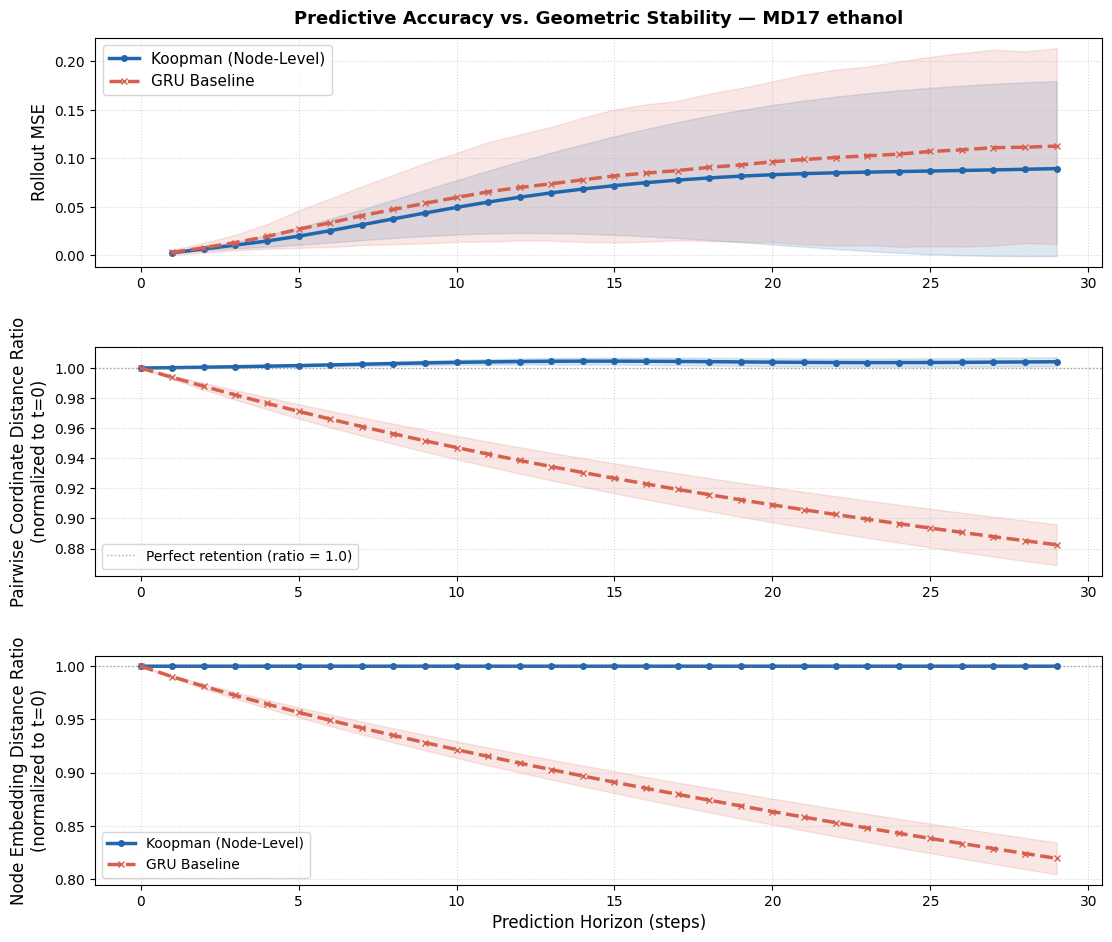

In [16]:
# ── Phase 6: Cell 6 - Run Evaluation (Node-Level Dynamics) ────────────────────
import os
import torch

# 1. Instantiate the Phase 6 models
graph_koopman_model = GraphKoopmanNet(node_dim=6, edge_dim=1, hidden_dim=64, latent_dim=576, n_atoms=9)
graph_gru_model = GraphGRUNet(node_dim=6, edge_dim=1, hidden_dim=64, latent_dim=576, n_atoms=9)

# 2. Reload the best checkpoints
koop_ckpt = torch.load(
    os.path.join(DIRS["checkpoints"], "graph_state_koopman_ethanol_best.pt"),
    weights_only=False
)
graph_koopman_model.load_state_dict(koop_ckpt["model_state_dict"])
print(f"Loaded best GNN-Koopman from epoch {koop_ckpt['epoch']}")

gru_ckpt = torch.load(
    os.path.join(DIRS["checkpoints"], "graph_state_gru_ethanol_best.pt"),
    weights_only=False
)
graph_gru_model.load_state_dict(gru_ckpt["model_state_dict"])
print(f"Loaded best GNN-GRU from epoch {gru_ckpt['epoch']}")

# 3. Run evaluation
graph_evaluator = GraphKoopmanEvaluator(
    koopman_model  = graph_koopman_model,
    baseline_model = graph_gru_model,
    device         = DEVICE,
    rollout_steps  = 29,
    batch_size     = 64,
)

graph_results = graph_evaluator.run(graph_test_split)

# 4. Print summary and show tradeoff plots
graph_evaluator.print_summary(graph_results)
graph_evaluator.plot(
    graph_results,
    save_path=os.path.join(DIRS["results"], "graph_node_dynamics_tradeoff.png")
)


In [17]:
# ── Phase 7: Cell 1 - Graph-Aware Models & Trainer ───────────────────────────
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import r2_score

class GraphAwareKoopmanNet(nn.Module):
    """
    Graph-Aware Koopman dynamics model with learnable coupling parameter alpha.
    """
    def __init__(self, edge_index, node_dim: int = 6, edge_dim: int = 1, hidden_dim: int = 64, latent_dim: int = 576, n_atoms: int = 9):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.n_atoms = n_atoms
        self.encoder = GraphEncoder(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=hidden_dim)
        self.decoder = GraphDecoder(state_dim=latent_dim, hidden_dim=128, n_atoms=n_atoms)
        self.A_self = nn.Parameter(torch.zeros(hidden_dim, hidden_dim))
        self.A_edge = nn.Parameter(torch.zeros(hidden_dim, hidden_dim))
        self.alpha = nn.Parameter(torch.tensor(0.1))

        self.register_buffer("edge_index", edge_index.clone())
        # Precompute P transition matrix
        P = torch.zeros(n_atoms, n_atoms)
        P[edge_index[1], edge_index[0]] = 1.0
        row_sums = P.sum(dim=1, keepdim=True)
        row_sums = torch.where(row_sums == 0, torch.ones_like(row_sums), row_sums)
        P = P / row_sums
        self.register_buffer("P", P)



    @property
    def K_global(self):
        A_self_skew = self.A_self - self.A_self.T
        A_edge_skew = self.A_edge - self.A_edge.T
        I_N = torch.eye(self.n_atoms, device=self.A_self.device)
        P_sym = 0.5 * (self.P + self.P.T)
        term_self = torch.kron(I_N, A_self_skew)
        term_edge = torch.kron(P_sym, A_edge_skew)
        A_glob = term_self + self.alpha * term_edge
        return torch.matrix_exp(A_glob)

    def forward(self, node_features, edge_index, edge_features, lengths):
        return self.encoder(node_features, edge_index, edge_features)

    def transition_step(self, h, K_glob=None):
        if h.dim() == 2:
            h = h.unsqueeze(0)
            is_2d = True
        else:
            is_2d = False

        B_steps, n_atoms, hidden_dim = h.shape
        h_flat = h.reshape(B_steps, n_atoms * hidden_dim)
        if K_glob is None:
            K_glob = self.K_global

        out_flat = torch.matmul(h_flat, K_glob.t())
        out = out_flat.reshape(B_steps, n_atoms, hidden_dim)

        if is_2d:
            out = out.squeeze(0)
        return out
    def forward_rollout(self, h0, steps=100, latent_seed=True):
        if latent_seed:
            h = h0[:, 0]  # (B, n_atoms, hidden_dim)
        else:
            raise NotImplementedError()
        rollout = [h]
        K_glob = self.K_global
        for _ in range(1, steps):
            h = self.transition_step(h, K_glob=K_glob)
            rollout.append(h)
        return torch.stack(rollout, dim=1)
    def get_global_K(self):
        return self.K_global.detach().cpu().numpy()
    def compute_loss(self, outputs, targets, lengths, epoch, node_features=None):
        h_seq = outputs  # (B, T, n_atoms, hidden_dim)
        B, T, n_atoms, hidden_dim = h_seq.shape

        h_t_list, h_tgt_list = [], []
        for b, L in enumerate(lengths):
            if L < 2: continue
            h_t_list.append(h_seq[b, :L-1])
            h_tgt_list.append(h_seq[b, 1:L])

        h_t = torch.cat(h_t_list, dim=0) # (Total_steps, n_atoms, hidden_dim)
        h_tgt = torch.cat(h_tgt_list, dim=0) # (Total_steps, n_atoms, hidden_dim)

        h_pred = self.transition_step(h_t)
        l_dyn = F.mse_loss(h_pred, h_tgt)

        step_diff = torch.norm(h_tgt - h_t, dim=-1)
        step_norm = torch.norm(h_t, dim=-1) + 1e-8
        relative_change = (step_diff / step_norm).mean()
        l_collapse = torch.relu(0.05 - relative_change)

        if node_features is not None:
            coords_true = node_features[:, :, :, :3]
            s_seq = h_seq.reshape(B, T, n_atoms * hidden_dim)
            coords_pred = self.decoder(s_seq)
            l_recon = F.mse_loss(coords_pred, coords_true)
            # Isometric regularization: penalize bonded distance distortion
            src_idx, dst_idx = self.edge_index[0], self.edge_index[1]
            d_true = torch.norm(coords_true[:, :, src_idx] - coords_true[:, :, dst_idx], dim=-1)
            d_pred = torch.norm(coords_pred[:, :, src_idx] - coords_pred[:, :, dst_idx], dim=-1)
            l_iso = F.mse_loss(d_pred, d_true)
        else:
            l_recon = 0.0
            l_iso = 0.0

        total_loss = l_dyn + 2.0 * l_collapse + 10.0 * l_recon + 5.0 * l_iso
        return total_loss, {
            'loss': total_loss.item(),
            'l_dyn': l_dyn.item(),
            'l_collapse': l_collapse.item(),
            'l_recon': l_recon.item() if node_features is not None else 0.0,
            'l_iso': l_iso.item() if node_features is not None else 0.0,
            'alpha': float(self.alpha.item())
        }

    def post_step_hook(self):
        pass


class GraphAwareGRUNet(nn.Module):
    def __init__(self, edge_index, node_dim: int = 6, edge_dim: int = 1, hidden_dim: int = 64, latent_dim: int = 576, n_atoms: int = 9):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.n_atoms = n_atoms
        self.encoder = GraphEncoder(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=hidden_dim)
        self.decoder = GraphDecoder(state_dim=latent_dim, hidden_dim=128, n_atoms=n_atoms)
        self.msg_proj = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.rnn_transition = nn.GRUCell(hidden_dim, hidden_dim)
        self.alpha = nn.Parameter(torch.tensor(0.1))

        self.register_buffer("edge_index", edge_index.clone())
        # Precompute P transition matrix
        P = torch.zeros(n_atoms, n_atoms)
        P[edge_index[1], edge_index[0]] = 1.0
        row_sums = P.sum(dim=1, keepdim=True)
        row_sums = torch.where(row_sums == 0, torch.ones_like(row_sums), row_sums)
        P = P / row_sums
        self.register_buffer("P", P)

    def forward(self, node_features, edge_index, edge_features, lengths):
        return self.encoder(node_features, edge_index, edge_features)

    def transition_step(self, h):
        if h.dim() == 2:
            h = h.unsqueeze(0)
            is_2d = True
        else:
            is_2d = False

        B_steps, n_atoms, hidden_dim = h.shape
        M = torch.matmul(self.P, h)
        M_proj = self.msg_proj(M)

        h_flat = h.reshape(-1, hidden_dim)
        m_flat = (self.alpha * M_proj).reshape(-1, hidden_dim)

        h_next_flat = self.rnn_transition(m_flat, h_flat)
        out = h_next_flat.reshape(B_steps, n_atoms, hidden_dim)

        if is_2d:
            out = out.squeeze(0)
        return out

    def forward_rollout(self, h0, steps=100, latent_seed=True):
        if latent_seed:
            h = h0[:, 0]  # (B, n_atoms, hidden_dim)
        else:
            raise NotImplementedError()
        rollout = [h]
        for _ in range(1, steps):
            h = self.transition_step(h)
            rollout.append(h)
        return torch.stack(rollout, dim=1)

    def compute_loss(self, outputs, targets, lengths, epoch, node_features=None):
        h_seq = outputs
        B, T, n_atoms, hidden_dim = h_seq.shape

        h_t_list, h_tgt_list = [], []
        for b, L in enumerate(lengths):
            if L < 2: continue
            h_t_list.append(h_seq[b, :L-1])
            h_tgt_list.append(h_seq[b, 1:L])

        h_t = torch.cat(h_t_list, dim=0)
        h_tgt = torch.cat(h_tgt_list, dim=0)

        h_pred = self.transition_step(h_t)
        l_dyn = F.mse_loss(h_pred, h_tgt)

        step_diff = torch.norm(h_tgt - h_t, dim=-1)
        step_norm = torch.norm(h_t, dim=-1) + 1e-8
        relative_change = (step_diff / step_norm).mean()
        l_collapse = torch.relu(0.05 - relative_change)

        if node_features is not None:
            coords_true = node_features[:, :, :, :3]
            s_seq = h_seq.reshape(B, T, n_atoms * hidden_dim)
            coords_pred = self.decoder(s_seq)
            l_recon = F.mse_loss(coords_pred, coords_true)
            # Isometric regularization: penalize bonded distance distortion
            src_idx, dst_idx = self.edge_index[0], self.edge_index[1]
            d_true = torch.norm(coords_true[:, :, src_idx] - coords_true[:, :, dst_idx], dim=-1)
            d_pred = torch.norm(coords_pred[:, :, src_idx] - coords_pred[:, :, dst_idx], dim=-1)
            l_iso = F.mse_loss(d_pred, d_true)
        else:
            l_recon = 0.0
            l_iso = 0.0

        total_loss = l_dyn + 2.0 * l_collapse + 10.0 * l_recon + 5.0 * l_iso
        return total_loss, {
            'loss': total_loss.item(),
            'l_dyn': l_dyn.item(),
            'l_collapse': l_collapse.item(),
            'l_recon': l_recon.item() if node_features is not None else 0.0,
            'l_iso': l_iso.item() if node_features is not None else 0.0,
            'alpha': float(self.alpha.item())
        }

    def post_step_hook(self):
        pass


class GraphAwareTrainer:
    """
    Trainer for Graph dynamics models (GraphAwareKoopmanNet and GraphAwareGRUNet).
    Guards checkpoints against trivial latent collapse.
    """
    def __init__(
        self,
        model,
        optimizer,
        checkpoint_dir,
        checkpoint_name="best.pt",
        epochs=100,
        batch_size=16,
        device="cpu",
        log_every=10,
    ):
        self.model           = model.to(device)
        self.optimizer       = optimizer
        self.checkpoint_dir  = checkpoint_dir
        self.checkpoint_name = checkpoint_name
        self.epochs          = epochs
        self.batch_size      = batch_size
        self.device          = device
        self.log_every       = log_every
        os.makedirs(checkpoint_dir, exist_ok=True)

    def fit(self, train_split: GraphDatasetSplit, val_split: GraphDatasetSplit):
        node_features_train = torch.tensor(train_split.node_features, dtype=torch.float32, device=self.device)
        edge_features_train = torch.tensor(train_split.edge_features, dtype=torch.float32, device=self.device)
        edge_index_train    = train_split.edge_index.to(self.device)
        train_lengths       = train_split.lengths

        node_features_val = torch.tensor(val_split.node_features, dtype=torch.float32, device=self.device)
        edge_features_val = torch.tensor(val_split.edge_features, dtype=torch.float32, device=self.device)
        edge_index_val    = val_split.edge_index.to(self.device)
        val_lengths       = val_split.lengths

        N = node_features_train.shape[0]
        best_r2   = -1e9
        best_info = {'epoch': -1, 'val_r2': -1e9}

        for epoch in range(1, self.epochs + 1):
            avg_log = self._train_epoch(
                node_features_train, edge_index_train, edge_features_train, train_lengths, N, epoch
            )
            val_r2 = self._compute_val_r2(
                node_features_val, edge_index_val, edge_features_val, val_lengths
            )
            # Save best checkpoint (ignoring collapsed epochs returning -1.0)
            if val_r2 > best_r2:
                best_r2 = val_r2
                best_info = {
                    'epoch':  epoch,
                    'val_r2': val_r2,
                }
                torch.save({
                    'epoch':            epoch,
                    'model_state_dict': self.model.state_dict(),
                    'val_r2':           val_r2,
                }, os.path.join(self.checkpoint_dir, self.checkpoint_name))

            if epoch % self.log_every == 0 or epoch == 1:
                alpha_str = f" | alpha {avg_log.get('alpha', 0):.4f}" if 'alpha' in avg_log else ""
                print(
                    f"Epoch {epoch:>3d}/{self.epochs} | "
                    f"Loss {avg_log.get('loss', 0):.4f} | "
                    f"l_dyn {avg_log.get('l_dyn', 0):.4f} | "
                    f"l_recon {avg_log.get('l_recon', 0):.4f}{alpha_str} | "
                    f"Val R\u00b2 {val_r2:.4f}  "
                    f"{'\u2190 BEST' if best_info.get('epoch') == epoch else ''}"
                )
        print(f"\nBest \u2192 epoch {best_info['epoch']}, Val R\u00b2 = {best_info['val_r2']:.4f}")
        return best_info

    def _train_epoch(self, node_feats, edge_idx, edge_feats, lengths, N, epoch):
        self.model.train()
        perm = torch.randperm(N)
        total_log   = {}
        num_batches = 0
        for start in range(0, N, self.batch_size):
            idx = perm[start : start + self.batch_size]
            batch_nodes = node_feats[idx]
            batch_edges = edge_feats[idx]
            batch_lens  = [lengths[i] for i in idx.tolist()]
            self.optimizer.zero_grad()
            h_seq = self.model(batch_nodes, edge_idx, batch_edges, batch_lens)
            loss, log = self.model.compute_loss(
                h_seq, targets=None, lengths=batch_lens, epoch=epoch, node_features=batch_nodes
            )
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            self.model.post_step_hook()
            for k, v in log.items():
                total_log[k] = total_log.get(k, 0.0) + v
            num_batches += 1
        return {k: v / num_batches for k, v in total_log.items()}

    @torch.no_grad()
    def _compute_val_r2(self, node_feats, edge_idx, edge_feats, val_lengths):
        self.model.eval()
        h_seq = self.model(node_feats, edge_idx, edge_feats, val_lengths)
        B, T, n_atoms, hidden_dim = h_seq.shape
        # Reject checkpoints if validation latent space collapsed
        all_ratios = []
        for b, L in enumerate(val_lengths):
            if L < 2: continue
            h_seq_b = h_seq[b, :L]
            h_seq_b_flat = h_seq_b.reshape(L, n_atoms * hidden_dim)
            diffs = (h_seq_b_flat[1:] - h_seq_b_flat[:-1]).norm(dim=1)
            norms = h_seq_b_flat[:-1].norm(dim=1) + 1e-8
            ratios = (diffs / norms).tolist()
            all_ratios.extend(ratios)

        mean_relative_change = np.mean(all_ratios) if all_ratios else 0.0
        if mean_relative_change < 0.05:
            return -1.0
        h_t_list, h_tgt_list = [], []
        for b, L in enumerate(val_lengths):
            if L < 2: continue
            h_t_list.append(h_seq[b, :L-1])
            h_tgt_list.append(h_seq[b, 1:L])
        h_t   = torch.cat(h_t_list,   dim=0)
        h_tgt = torch.cat(h_tgt_list, dim=0)
        h_pred = self.model.transition_step(h_t)
        y_true = h_tgt.cpu().numpy()
        y_pred = h_pred.cpu().numpy()
        r2 = r2_score(y_true.ravel(), y_pred.ravel())
        self.model.train()
        return r2

print("Phase 7 models and trainer defined.")


Phase 7 models and trainer defined.


In [18]:
# ── Phase 7: Cell 2 - Graph-Aware Evaluator & Plotting ──────────────────────
from typing import Optional
from dataclasses import dataclass, field
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class GraphAwareEvalResults:
    """
    Evaluation results container for graph-aware dynamics.
    """
    koopman_mse_mean : np.ndarray
    koopman_mse_std  : np.ndarray
    baseline_mse_mean: np.ndarray
    baseline_mse_std : np.ndarray

    rho_koopman      : float

    koopman_geom_mean : np.ndarray
    koopman_geom_std  : np.ndarray
    baseline_geom_mean: np.ndarray
    baseline_geom_std : np.ndarray

    koopman_node_geom_mean : np.ndarray
    koopman_node_geom_std  : np.ndarray
    baseline_node_geom_mean: np.ndarray
    baseline_node_geom_std : np.ndarray

    koopman_energy_mean : np.ndarray
    koopman_energy_std  : np.ndarray
    baseline_energy_mean: np.ndarray
    baseline_energy_std : np.ndarray

    relative_change_koopman : float
    relative_change_baseline: float

    meta: dict = field(default_factory=dict)


class GraphAwareKoopmanEvaluator:
    """
    Evaluator for Graph-Aware dynamics models. Computes rollout MSE, spectral radius of the Kronecker
    operator K_global, dual geometry retention ratios, and rollout Graph Energy.
    """
    def __init__(
        self,
        koopman_model  : nn.Module,
        baseline_model : nn.Module,
        device         : str = 'cpu',
        rollout_steps  : int = 29,
        batch_size     : int = 64,
        n_atoms        : int = 9,
        hidden_dim     : int = 64
    ):
        self.koopman_model  = koopman_model.to(device).eval()
        self.baseline_model = baseline_model.to(device).eval()
        self.device         = device
        self.rollout_steps  = rollout_steps
        self.batch_size     = batch_size
        self.n_atoms        = n_atoms
        self.hidden_dim     = hidden_dim

    def run(self, split: GraphDatasetSplit) -> GraphAwareEvalResults:
        node_feats = torch.tensor(split.node_features, dtype=torch.float32, device=self.device)
        edge_feats = torch.tensor(split.edge_features, dtype=torch.float32, device=self.device)
        edge_idx   = split.edge_index.to(self.device)
        lengths    = split.lengths

        with torch.no_grad():
            z_koop = self._encode_all(self.koopman_model, node_feats, edge_idx, edge_feats, lengths)
            z_base = self._encode_all(self.baseline_model, node_feats, edge_idx, edge_feats, lengths)

            koop_mse_mean, koop_mse_std = self._rollout_mse(self.koopman_model, z_koop, lengths)
            base_mse_mean, base_mse_std = self._rollout_mse(self.baseline_model, z_base, lengths)

            rho_koopman = self._spectral_radii(self.koopman_model)

            # Coordinate geometry retention (physical geometry ratio)
            koop_geom_mean, koop_geom_std = self._coordinate_geometry_retention(self.koopman_model, z_koop, lengths)
            base_geom_mean, base_geom_std = self._coordinate_geometry_retention(self.baseline_model, z_base, lengths)

            # Node embedding geometry retention (embedding geometry ratio)
            k_node_geom_mean, k_node_geom_std = self._node_geometry_retention(self.koopman_model, z_koop, lengths)
            b_node_geom_mean, b_node_geom_std = self._node_geometry_retention(self.baseline_model, z_base, lengths)

            # Graph energy ratio
            k_energy_mean, k_energy_std = self._graph_energy_retention(self.koopman_model, z_koop, lengths)
            b_energy_mean, b_energy_std = self._graph_energy_retention(self.baseline_model, z_base, lengths)

            rc_koop = self._relative_change(z_koop, lengths)
            rc_base = self._relative_change(z_base, lengths)

        return GraphAwareEvalResults(
            koopman_mse_mean        = koop_mse_mean,
            koopman_mse_std         = koop_mse_std,
            baseline_mse_mean       = base_mse_mean,
            baseline_mse_std        = base_mse_std,
            rho_koopman             = rho_koopman,
            koopman_geom_mean       = koop_geom_mean,
            koopman_geom_std        = koop_geom_std,
            baseline_geom_mean      = base_geom_mean,
            baseline_geom_std       = base_geom_std,
            koopman_node_geom_mean  = k_node_geom_mean,
            koopman_node_geom_std   = k_node_geom_std,
            baseline_node_geom_mean = b_node_geom_mean,
            baseline_node_geom_std  = b_node_geom_std,
            koopman_energy_mean     = k_energy_mean,
            koopman_energy_std      = k_energy_std,
            baseline_energy_mean    = b_energy_mean,
            baseline_energy_std     = b_energy_std,
            relative_change_koopman = rc_koop,
            relative_change_baseline= rc_base,
            meta                    = split.meta,
        )

    def _encode_all(self, model, node_feats, edge_idx, edge_feats, lengths):
        N = node_feats.shape[0]
        z_list = []
        for start in range(0, N, self.batch_size):
            end = min(start + self.batch_size, N)
            batch_nodes = node_feats[start:end]
            batch_edges = edge_feats[start:end]
            batch_lens  = lengths[start:end]
            z_batch     = model(batch_nodes, edge_idx, batch_edges, batch_lens)
            z_list.append(z_batch)
        return torch.cat(z_list, dim=0)

    def _rollout_mse(self, model, z, lengths):
        z_cpu = z.cpu()
        mse_per_step_mean = np.zeros(self.rollout_steps)
        mse_per_step_std  = np.zeros(self.rollout_steps)

        if not hasattr(model, 'get_global_K'):
            # GRU model (calls forward_rollout starting from frame 0)
            for s in range(1, self.rollout_steps + 1):
                errors = []
                for b, T in enumerate(lengths):
                    if T <= s + 1:
                        continue
                    seed = z_cpu[b:b+1, :1, :, :]
                    preds = model.forward_rollout(
                        seed.to(self.device), steps=s + 1, latent_seed=True
                    ).cpu()
                    z_pred   = preds[0, s]
                    z_target = z_cpu[b, s]
                    errors.append(F.mse_loss(z_pred, z_target).item())
                mse_per_step_mean[s - 1] = np.mean(errors) if errors else 0.0
                mse_per_step_std[s - 1]  = np.std(errors)  if errors else 0.0
        else:
            # Koopman model (calls transition_step across all sequence frames in parallel)
            for s in range(1, self.rollout_steps + 1):
                errors = []
                for b, T in enumerate(lengths):
                    if T <= s + 1:
                        continue
                    z_init   = z[b, :T - s].to(self.device)  # (T-s, 9, 64)
                    z_target = z[b, s:T].to(self.device)     # (T-s, 9, 64)

                    h = z_init
                    for _ in range(s):
                        h = model.transition_step(h)
                    errors.append(F.mse_loss(h, z_target).item())
                mse_per_step_mean[s - 1] = np.mean(errors) if errors else 0.0
                mse_per_step_std[s - 1]  = np.std(errors)  if errors else 0.0

        return mse_per_step_mean, mse_per_step_std

    def _spectral_radii(self, model):
        if not hasattr(model, 'get_global_K'):
            return 0.0
        K_global = model.get_global_K()
        eigvals = np.linalg.eigvals(K_global)
        return float(np.max(np.abs(eigvals)))

    def _coordinate_geometry_retention(self, model, z, lengths):
        N = len(lengths)
        geom_means = np.zeros(self.rollout_steps + 1)
        geom_stds  = np.zeros(self.rollout_steps + 1)

        with torch.no_grad():
            z_all_0 = z.to(self.device)[:, :1, :, :]
            rollout_all = model.forward_rollout(z_all_0, steps=self.rollout_steps + 1, latent_seed=True)

            B, steps, n_atoms, h_dim = rollout_all.shape
            rollout_all_flat = rollout_all.reshape(B * steps, n_atoms * h_dim)
            coords_all_flat = model.decoder(rollout_all_flat)
            coords_all = coords_all_flat.reshape(B, steps, n_atoms, 3).cpu()

        for s in range(self.rollout_steps + 1):
            ratios = []
            for b in range(N):
                if lengths[b] <= s:
                    continue
                X0 = coords_all[b, 0]
                Xs = coords_all[b, s]
                D0 = torch.norm(X0.unsqueeze(1) - X0.unsqueeze(0), dim=-1)
                Ds = torch.norm(Xs.unsqueeze(1) - Xs.unsqueeze(0), dim=-1)
                norm_D0 = torch.norm(D0).item()
                if norm_D0 < 1e-8:
                    continue
                ratio = torch.norm(Ds).item() / norm_D0
                ratios.append(ratio)
            geom_means[s] = np.mean(ratios) if ratios else 0.0
            geom_stds[s]  = np.std(ratios)  if ratios else 0.0

        return geom_means, geom_stds

    def _node_geometry_retention(self, model, z, lengths):
        N = len(lengths)
        geom_means = np.zeros(self.rollout_steps + 1)
        geom_stds  = np.zeros(self.rollout_steps + 1)

        with torch.no_grad():
            z_all_0 = z.to(self.device)[:, :1, :, :]
            rollout_all = model.forward_rollout(z_all_0, steps=self.rollout_steps + 1, latent_seed=True).cpu()

        for s in range(self.rollout_steps + 1):
            ratios = []
            for b in range(N):
                if lengths[b] <= s:
                    continue
                H0 = rollout_all[b, 0]
                Hs = rollout_all[b, s]
                D0 = torch.norm(H0.unsqueeze(1) - H0.unsqueeze(0), dim=-1)
                Ds = torch.norm(Hs.unsqueeze(1) - Hs.unsqueeze(0), dim=-1)
                norm_D0 = torch.norm(D0).item()
                if norm_D0 < 1e-8:
                    continue
                ratio = torch.norm(Ds).item() / norm_D0
                ratios.append(ratio)
            geom_means[s] = np.mean(ratios) if ratios else 0.0
            geom_stds[s]  = np.std(ratios)  if ratios else 0.0

        return geom_means, geom_stds

    def _graph_energy_retention(self, model, z, lengths):
        N = len(lengths)
        energy_means = np.zeros(self.rollout_steps + 1)
        energy_stds  = np.zeros(self.rollout_steps + 1)

        with torch.no_grad():
            z_all_0 = z.to(self.device)[:, :1, :, :]
            rollout_all = model.forward_rollout(z_all_0, steps=self.rollout_steps + 1, latent_seed=True).cpu()

        for s in range(self.rollout_steps + 1):
            ratios = []
            for b in range(N):
                if lengths[b] <= s:
                    continue
                H0 = rollout_all[b, 0]
                Hs = rollout_all[b, s]
                E0 = torch.mean(torch.norm(H0, dim=-1)**2).item()
                Es = torch.mean(torch.norm(Hs, dim=-1)**2).item()
                if E0 < 1e-8:
                    continue
                ratios.append(Es / E0)
            energy_means[s] = np.mean(ratios) if ratios else 0.0
            energy_stds[s]  = np.std(ratios)  if ratios else 0.0

        return energy_means, energy_stds

    def _relative_change(self, z, lengths):
        z_cpu = z.cpu()
        all_ratios = []
        for b, T in enumerate(lengths):
            if T < 2:
                continue
            z_seq = z_cpu[b, :T]
            z_seq_flat = z_seq.reshape(T, -1)
            diffs = (z_seq_flat[1:] - z_seq_flat[:-1]).norm(dim=1)
            norms = z_seq_flat[:-1].norm(dim=1)
            ratios = (diffs / (norms + 1e-6)).tolist()
            all_ratios.extend(ratios)
        return float(np.mean(all_ratios)) if all_ratios else 0.0

    def print_summary(self, results: GraphAwareEvalResults):
        sep = "=" * 70
        print(sep)
        print(f"EVALUATION SUMMARY — {results.meta.get('dataset','?')} {results.meta.get('molecule','')}")
        print(sep)
        print("\n[1] ROLLOUT MSE")
        print(f"  {'Step':>4}  {'Koopman':>12}  {'Baseline':>12}")
        for s in range(len(results.koopman_mse_mean)):
            print(f"  {s+1:>4}  {results.koopman_mse_mean[s]:>12.4e}  {results.baseline_mse_mean[s]:>12.4e}")

        print("\n[2] SPECTRAL RADIUS")
        print(f"  rho(K_global): {results.rho_koopman:.6f}  "
              f"{'PASS (conservative)' if abs(results.rho_koopman - 1.0) < 5e-2 else 'WARN'}")

        print("\n[3] GEOMETRY RETENTION @ final step")
        print(f"  Koopman Coordinate Retention : {results.koopman_geom_mean[-1]:.4f}")
        print(f"  Baseline Coordinate Retention: {results.baseline_geom_mean[-1]:.4f}")
        print(f"  Koopman Node Emb. Retention  : {results.koopman_node_geom_mean[-1]:.4f}")
        print(f"  Baseline Node Emb. Retention : {results.baseline_node_geom_mean[-1]:.4f}")

        print("\n[4] GRAPH ENERGY @ final step")
        print(f"  Koopman Graph Energy Ratio   : {results.koopman_energy_mean[-1]:.4f}")
        print(f"  Baseline Graph Energy Ratio  : {results.baseline_energy_mean[-1]:.4f}")

        print("\n[5] COLLAPSE DIAGNOSTIC")
        print(f"  Koopman  relative change: {results.relative_change_koopman:.4f}  "
              f"{'PASS' if results.relative_change_koopman > 0.05 else 'FAIL'}")
        print(f"  Baseline relative change: {results.relative_change_baseline:.4f}")
        print(sep)

    def plot(self, results: GraphAwareEvalResults, title: Optional[str] = None, save_path: Optional[str] = None):
        KOOP_COLOR = "#2166ac"
        BASE_COLOR = "#d6604d"

        steps_err  = np.arange(1, self.rollout_steps + 1)
        steps_geom = np.arange(0, self.rollout_steps + 1)

        k0 = results.koopman_geom_mean[0] + 1e-8
        b0 = results.baseline_geom_mean[0] + 1e-8
        koop_geom_norm = results.koopman_geom_mean  / k0
        base_geom_norm = results.baseline_geom_mean / b0
        koop_gstd_norm = results.koopman_geom_std   / k0
        base_gstd_norm = results.baseline_geom_std  / b0

        k_node0 = results.koopman_node_geom_mean[0] + 1e-8
        b_node0 = results.baseline_node_geom_mean[0] + 1e-8
        koop_node_norm = results.koopman_node_geom_mean / k_node0
        base_node_norm = results.baseline_node_geom_mean / b_node0
        koop_nstd_norm = results.koopman_node_geom_std / k_node0
        base_nstd_norm = results.baseline_node_geom_std / b_node0

        dataset_label = (title or f"{results.meta.get('dataset','?')} {results.meta.get('molecule','')}")

        fig = plt.figure(figsize=(13, 14))
        gs  = gridspec.GridSpec(4, 1, hspace=0.35)

        # 1. MSE
        ax1 = fig.add_subplot(gs[0])
        ax1.plot(steps_err, results.koopman_mse_mean, color=KOOP_COLOR, linewidth=2.5, marker='o', markersize=4, label='Koopman (Graph-Aware)')
        ax1.fill_between(steps_err, results.koopman_mse_mean - results.koopman_mse_std, results.koopman_mse_mean + results.koopman_mse_std, color=KOOP_COLOR, alpha=0.15)
        ax1.plot(steps_err, results.baseline_mse_mean, color=BASE_COLOR, linewidth=2.5, linestyle='--', marker='x', markersize=5, label='GRU Baseline')
        ax1.fill_between(steps_err, results.baseline_mse_mean - results.baseline_mse_std, results.baseline_mse_mean + results.baseline_mse_std, color=BASE_COLOR, alpha=0.15)
        ax1.set_ylabel("Rollout MSE", fontsize=12)
        ax1.set_title(f"Predictive Accuracy vs. Geometric Stability — {dataset_label}", fontsize=13, fontweight='bold', pad=10)
        ax1.legend(fontsize=11, loc='upper left')
        ax1.grid(True, linestyle=':', alpha=0.5)

        # 2. Coordinate Geometry Retention
        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2.plot(steps_geom, koop_geom_norm, color=KOOP_COLOR, linewidth=2.5, marker='o', markersize=4)
        ax2.fill_between(steps_geom, koop_geom_norm - koop_gstd_norm, koop_geom_norm + koop_gstd_norm, color=KOOP_COLOR, alpha=0.15)
        ax2.plot(steps_geom, base_geom_norm, color=BASE_COLOR, linewidth=2.5, linestyle='--', marker='x', markersize=5)
        ax2.fill_between(steps_geom, base_geom_norm - base_gstd_norm, base_geom_norm + base_gstd_norm, color=BASE_COLOR, alpha=0.15)
        ax2.axhline(1.0, color='gray', linewidth=1.0, linestyle=':', alpha=0.7, label='Perfect retention (ratio = 1.0)')
        ax2.set_ylabel("Pairwise Coordinate Distance Ratio\n(normalized to t=0)", fontsize=12)
        ax2.legend(fontsize=10, loc='lower left')
        ax2.grid(True, linestyle=':', alpha=0.5)

        # 3. Node Embedding Geometry Retention
        ax3 = fig.add_subplot(gs[2], sharex=ax1)
        ax3.plot(steps_geom, koop_node_norm, color=KOOP_COLOR, linewidth=2.5, marker='o', markersize=4, label='Koopman (Graph-Aware)')
        ax3.fill_between(steps_geom, koop_node_norm - koop_nstd_norm, koop_node_norm + koop_nstd_norm, color=KOOP_COLOR, alpha=0.15)
        ax3.plot(steps_geom, base_node_norm, color=BASE_COLOR, linewidth=2.5, linestyle='--', marker='x', markersize=5, label='GRU Baseline')
        ax3.fill_between(steps_geom, base_node_norm - base_nstd_norm, base_node_norm + base_nstd_norm, color=BASE_COLOR, alpha=0.15)
        ax3.axhline(1.0, color='gray', linewidth=1.0, linestyle=':', alpha=0.7)
        ax3.set_ylabel("Node Embedding Distance Ratio\n(normalized to t=0)", fontsize=12)
        ax3.legend(fontsize=10, loc='lower left')
        ax3.grid(True, linestyle=':', alpha=0.5)

        # 4. Graph Energy Retention
        ax4 = fig.add_subplot(gs[3], sharex=ax1)
        ax4.plot(steps_geom, results.koopman_energy_mean, color=KOOP_COLOR, linewidth=2.5, marker='o', markersize=4, label='Koopman (Graph-Aware)')
        ax4.fill_between(steps_geom, results.koopman_energy_mean - results.koopman_energy_std, results.koopman_energy_mean + results.koopman_energy_std, color=KOOP_COLOR, alpha=0.15)
        ax4.plot(steps_geom, results.baseline_energy_mean, color=BASE_COLOR, linewidth=2.5, linestyle='--', marker='x', markersize=5, label='GRU Baseline')
        ax4.fill_between(steps_geom, results.baseline_energy_mean - results.baseline_energy_std, results.baseline_energy_mean + results.baseline_energy_std, color=BASE_COLOR, alpha=0.15)
        ax4.axhline(1.0, color='gray', linewidth=1.0, linestyle=':', alpha=0.7)
        ax4.set_xlabel("Prediction Horizon (steps)", fontsize=12)
        ax4.set_ylabel("Graph Energy Ratio (Et / E0)\n(normalized to t=0)", fontsize=12)
        ax4.legend(fontsize=10, loc='lower left')
        ax4.grid(True, linestyle=':', alpha=0.5)

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

print("Phase 7 evaluator and plotting helpers defined.")


Phase 7 evaluator and plotting helpers defined.


In [19]:
# ── Phase 7: Cell 3 - Train, Visualize and Evaluate (Graph-Aware Dynamics) ──
import random
import numpy as np

# Fix seeds for absolute reproducibility across runs
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

import os
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Train models with decoders and graph connectivity
print("Initializing GraphAwareKoopmanNet...")
graph_koopman_model = GraphAwareKoopmanNet(
    edge_index=graph_train_split.edge_index,
    node_dim=6, edge_dim=1, hidden_dim=64, latent_dim=576, n_atoms=9
)
koopman_optimizer = torch.optim.AdamW(graph_koopman_model.parameters(), lr=1e-3, weight_decay=1e-4)
koopman_trainer = GraphAwareTrainer(
    model           = graph_koopman_model,
    optimizer       = koopman_optimizer,
    checkpoint_dir  = DIRS["checkpoints"],
    checkpoint_name = "graph_aware_koopman_ethanol_best.pt",
    epochs          = 100,
    batch_size      = 16,
    device          = DEVICE,
    log_every       = 10,
)
print("Training GraphAwareKoopmanNet...")
koopman_trainer.fit(graph_train_split, graph_test_split)

print("\nInitializing GraphAwareGRUNet...")
graph_gru_model = GraphAwareGRUNet(
    edge_index=graph_train_split.edge_index,
    node_dim=6, edge_dim=1, hidden_dim=64, latent_dim=576, n_atoms=9
)
gru_optimizer = torch.optim.AdamW(graph_gru_model.parameters(), lr=1e-3, weight_decay=1e-4)
gru_trainer = GraphAwareTrainer(
    model           = graph_gru_model,
    optimizer       = gru_optimizer,
    checkpoint_dir  = DIRS["checkpoints"],
    checkpoint_name = "graph_aware_gru_ethanol_best.pt",
    epochs          = 100,
    batch_size      = 16,
    device          = DEVICE,
    log_every       = 10,
)
print("Training GraphAwareGRUNet...")
gru_trainer.fit(graph_train_split, graph_test_split)

# 2. Reload best checkpoints
koop_ckpt = torch.load(os.path.join(DIRS["checkpoints"], "graph_aware_koopman_ethanol_best.pt"), weights_only=False)
graph_koopman_model.load_state_dict(koop_ckpt["model_state_dict"])
print(f"Loaded best Graph-Aware Koopman from epoch {koop_ckpt['epoch']}")

gru_ckpt = torch.load(os.path.join(DIRS["checkpoints"], "graph_aware_gru_ethanol_best.pt"), weights_only=False)
graph_gru_model.load_state_dict(gru_ckpt["model_state_dict"])
print(f"Loaded best Graph-Aware GRU from epoch {gru_ckpt['epoch']}")

# 3. Project test split into latent states
graph_koopman_model.eval()
graph_gru_model.eval()

# 5. Run evaluation and plot metrics
graph_evaluator = GraphAwareKoopmanEvaluator(
    koopman_model  = graph_koopman_model,
    baseline_model = graph_gru_model,
    device         = DEVICE,
    rollout_steps  = 29,
    batch_size     = 64,
)

graph_results = graph_evaluator.run(graph_test_split)
graph_evaluator.print_summary(graph_results)
graph_evaluator.plot(
    graph_results,
    save_path=os.path.join(DIRS["results"], "graph_aware_dynamics_tradeoff.png")
)


Initializing GraphAwareKoopmanNet...
Training GraphAwareKoopmanNet...
Epoch   1/100 | Loss 5.5444 | l_dyn 0.0001 | l_recon 0.5512 | alpha 0.0949 | Val R² -1.0000  ← BEST
Epoch  10/100 | Loss 0.1021 | l_dyn 0.0030 | l_recon 0.0099 | alpha 0.0135 | Val R² 0.9901  
Epoch  20/100 | Loss 0.0398 | l_dyn 0.0024 | l_recon 0.0037 | alpha 0.0187 | Val R² 0.9896  
Epoch  30/100 | Loss 0.0252 | l_dyn 0.0021 | l_recon 0.0023 | alpha 0.0208 | Val R² 0.9885  
Epoch  40/100 | Loss 0.0192 | l_dyn 0.0018 | l_recon 0.0017 | alpha 0.0226 | Val R² 0.9881  
Epoch  50/100 | Loss 0.0128 | l_dyn 0.0016 | l_recon 0.0011 | alpha 0.0248 | Val R² 0.9873  
Epoch 100/100 | Loss 0.0047 | l_dyn 0.0010 | l_recon 0.0004 | alpha 0.0231 | Val R² 0.9872  

Best → epoch 2, Val R² = 0.9909

Initializing GraphAwareGRUNet...
Training GraphAwareGRUNet...
Epoch   1/100 | Loss 5.2369 | l_dyn 0.0047 | l_recon 0.5209 | alpha 0.1050 | Val R² -1.0000  ← BEST
Epoch  10/100 | Loss 0.1048 | l_dyn 0.0028 | l_recon 0.0102 | alpha 0.2064 |

: 

Found 8 bonds, 13 angles, 12 torsions.


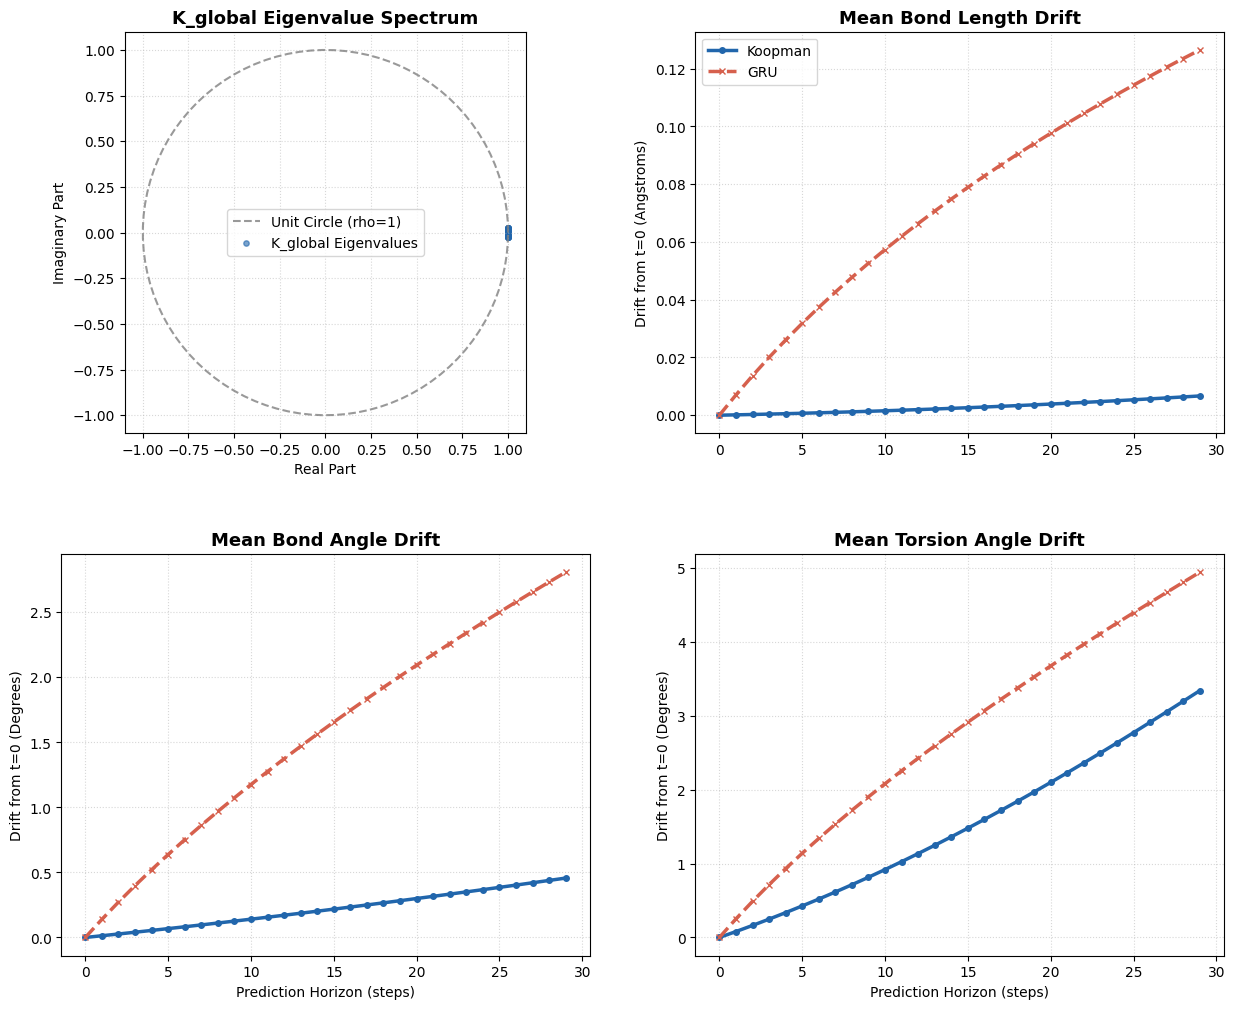

In [ ]:
# ── Phase 7.1: Deep Physical Diagnostics (Bonds, Angles, Torsions) ─────────────
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch

def extract_topology(edge_index, n_atoms):
    G = nx.Graph()
    G.add_nodes_from(range(n_atoms))
    edges = edge_index.cpu().T.numpy().tolist()
    G.add_edges_from(edges)

    bonds = list(G.edges())

    angles = []
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        for i in range(len(neighbors)):
            for j in range(i+1, len(neighbors)):
                angles.append((neighbors[i], node, neighbors[j]))

    torsions = []
    for u, v in G.edges():
        for w in G.neighbors(u):
            if w == v: continue
            for x in G.neighbors(v):
                if x == u or x == w: continue
                torsions.append((w, u, v, x))

    return bonds, angles, torsions

def compute_angles(coords, angles):
    # coords shape: (B, steps, n_atoms, 3)
    # angles: list of (i, j, k) where j is the central atom
    vals = []
    for i, j, k in angles:
        v1 = coords[..., i, :] - coords[..., j, :]
        v2 = coords[..., k, :] - coords[..., j, :]
        v1_norm = torch.norm(v1, dim=-1)
        v2_norm = torch.norm(v2, dim=-1)
        dot = torch.sum(v1 * v2, dim=-1)
        cos_theta = torch.clamp(dot / (v1_norm * v2_norm + 1e-8), -1.0, 1.0)
        theta = torch.acos(cos_theta) * (180.0 / np.pi)
        vals.append(theta)
    if not vals: return None
    return torch.stack(vals, dim=-1)  # (B, steps, num_angles)

def compute_torsions(coords, torsions):
    vals = []
    for i, j, k, l in torsions:
        b1 = coords[..., j, :] - coords[..., i, :]
        b2 = coords[..., k, :] - coords[..., j, :]
        b3 = coords[..., l, :] - coords[..., k, :]

        n1 = torch.cross(b1, b2, dim=-1)
        n2 = torch.cross(b2, b3, dim=-1)

        n1_norm = torch.norm(n1, dim=-1)
        n2_norm = torch.norm(n2, dim=-1)

        dot = torch.sum(n1 * n2, dim=-1)
        cos_phi = torch.clamp(dot / (n1_norm * n2_norm + 1e-8), -1.0, 1.0)
        phi = torch.acos(cos_phi) * (180.0 / np.pi)
        vals.append(phi)
    if not vals: return None
    return torch.stack(vals, dim=-1)

def run_deep_diagnostics(koop_model, gru_model, test_split, steps=29):
    koop_model.eval()
    gru_model.eval()
    bonds, angles, torsions = extract_topology(test_split.edge_index, n_atoms=9)

    print(f"Found {len(bonds)} bonds, {len(angles)} angles, {len(torsions)} torsions.")

    node_feats = torch.tensor(test_split.node_features, dtype=torch.float32, device=DEVICE)
    edge_feats = torch.tensor(test_split.edge_features, dtype=torch.float32, device=DEVICE)
    edge_idx = test_split.edge_index.to(DEVICE)
    lengths = test_split.lengths

    with torch.no_grad():
        # Encode starting states
        z_koop = []
        z_gru = []
        for start in range(0, len(node_feats), 64):
            end = min(start + 64, len(node_feats))
            z_koop.append(koop_model(node_feats[start:end], edge_idx, edge_feats[start:end], lengths[start:end]))
            z_gru.append(gru_model(node_feats[start:end], edge_idx, edge_feats[start:end], lengths[start:end]))
        z_koop = torch.cat(z_koop, dim=0)
        z_gru = torch.cat(z_gru, dim=0)

        z_koop_0 = z_koop[:, :1]
        z_gru_0 = z_gru[:, :1]

        roll_koop = koop_model.forward_rollout(z_koop_0, steps=steps+1, latent_seed=True)
        roll_gru = gru_model.forward_rollout(z_gru_0, steps=steps+1, latent_seed=True)

        B = roll_koop.shape[0]
        n_atoms, h_dim = 9, 64

        coords_koop = koop_model.decoder(roll_koop.reshape(B * (steps+1), n_atoms * h_dim)).reshape(B, steps+1, n_atoms, 3).cpu()
        coords_gru = gru_model.decoder(roll_gru.reshape(B * (steps+1), n_atoms * h_dim)).reshape(B, steps+1, n_atoms, 3).cpu()

    def calc_drifts(coords):
        # Bonds
        b_vals = []
        for i, j in bonds:
            b_vals.append(torch.norm(coords[..., i, :] - coords[..., j, :], dim=-1))
        b_vals = torch.stack(b_vals, dim=-1) # (B, steps, num_bonds)
        b_drift = torch.mean(torch.abs(b_vals - b_vals[:, 0:1, :]), dim=(0, 2)).numpy()

        # Angles
        a_vals = compute_angles(coords, angles)
        a_drift = torch.mean(torch.abs(a_vals - a_vals[:, 0:1, :]), dim=(0, 2)).numpy() if a_vals is not None else np.zeros(steps+1)

        # Torsions
        t_vals = compute_torsions(coords, torsions)
        t_drift = torch.mean(torch.abs(t_vals - t_vals[:, 0:1, :]), dim=(0, 2)).numpy() if t_vals is not None else np.zeros(steps+1)

        return b_drift, a_drift, t_drift

    kb, ka, kt = calc_drifts(coords_koop)
    gb, ga, gt = calc_drifts(coords_gru)

    return (kb, ka, kt), (gb, ga, gt)

koop_drifts, gru_drifts = run_deep_diagnostics(graph_koopman_model, graph_gru_model, graph_test_split, steps=29)

# Plotting
fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.2)

steps_arr = np.arange(30)

# 1. Eigenvalue Spectrum
ax1 = fig.add_subplot(gs[0, 0])
K_glob = graph_koopman_model.get_global_K()
eigvals = np.linalg.eigvals(K_glob)
theta = np.linspace(0, 2*np.pi, 100)
ax1.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', alpha=0.8, label='Unit Circle (rho=1)')
ax1.scatter(eigvals.real, eigvals.imag, color='#2166ac', alpha=0.6, s=15, label='K_global Eigenvalues')
ax1.set_aspect('equal')
ax1.set_title("K_global Eigenvalue Spectrum", fontsize=13, fontweight='bold')
ax1.set_xlabel("Real Part")
ax1.set_ylabel("Imaginary Part")
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend()

# 2. Bond Drift
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(steps_arr, koop_drifts[0], color='#2166ac', linewidth=2.5, marker='o', markersize=4, label='Koopman')
ax2.plot(steps_arr, gru_drifts[0], color='#d6604d', linewidth=2.5, linestyle='--', marker='x', markersize=5, label='GRU')
ax2.set_title("Mean Bond Length Drift", fontsize=13, fontweight='bold')
ax2.set_ylabel("Drift from t=0 (Angstroms)")
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend()

# 3. Angle Drift
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(steps_arr, koop_drifts[1], color='#2166ac', linewidth=2.5, marker='o', markersize=4)
ax3.plot(steps_arr, gru_drifts[1], color='#d6604d', linewidth=2.5, linestyle='--', marker='x', markersize=5)
ax3.set_title("Mean Bond Angle Drift", fontsize=13, fontweight='bold')
ax3.set_xlabel("Prediction Horizon (steps)")
ax3.set_ylabel("Drift from t=0 (Degrees)")
ax3.grid(True, linestyle=':', alpha=0.5)

# 4. Torsion Drift
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(steps_arr, koop_drifts[2], color='#2166ac', linewidth=2.5, marker='o', markersize=4)
ax4.plot(steps_arr, gru_drifts[2], color='#d6604d', linewidth=2.5, linestyle='--', marker='x', markersize=5)
ax4.set_title("Mean Torsion Angle Drift", fontsize=13, fontweight='bold')
ax4.set_xlabel("Prediction Horizon (steps)")
ax4.set_ylabel("Drift from t=0 (Degrees)")
ax4.grid(True, linestyle=':', alpha=0.5)

plt.savefig(os.path.join(DIRS['results'], 'physical_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()


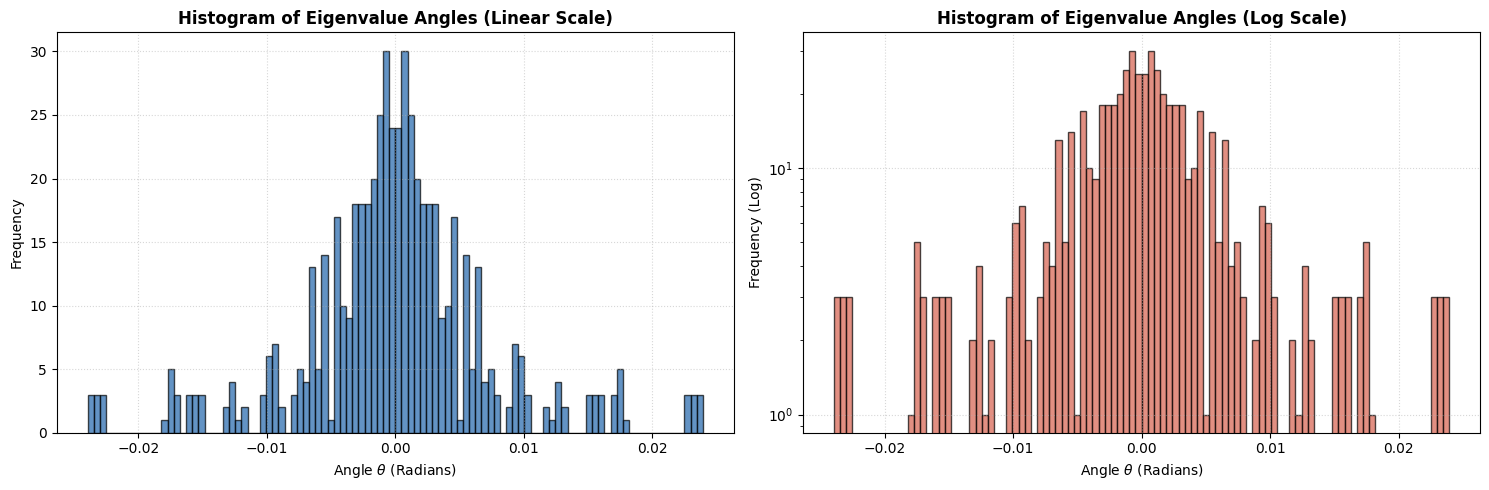

Total Eigenvalues: 576
Modes strictly at θ ≈ 0 (<1e-3 rad): 120 (20.8%)
Maximum angular velocity |θ_max|: 0.0239 rad/step


In [ ]:
# ── Phase 7.2: Eigenvalue Angle Spectrum (Testing for "Do Nothing" mode) ──────
import numpy as np
import matplotlib.pyplot as plt

K_glob = graph_koopman_model.get_global_K()
eigvals = np.linalg.eigvals(K_glob)
angles = np.angle(eigvals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Linear Scale
ax1.hist(angles, bins=100, color='#2166ac', edgecolor='black', alpha=0.7)
ax1.set_title("Histogram of Eigenvalue Angles (Linear Scale)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Angle $\\theta$ (Radians)")
ax1.set_ylabel("Frequency")
ax1.grid(True, linestyle=':', alpha=0.5)

# Log Scale (to see the tail distributions)
ax2.hist(angles, bins=100, color='#d6604d', edgecolor='black', alpha=0.7)
ax2.set_title("Histogram of Eigenvalue Angles (Log Scale)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Angle $\\theta$ (Radians)")
ax2.set_ylabel("Frequency (Log)")
ax2.set_yscale('log')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

zero_modes = np.sum(np.abs(angles) < 1e-3)
print(f"Total Eigenvalues: {len(angles)}")
print(f"Modes strictly at θ ≈ 0 (<1e-3 rad): {zero_modes} ({(zero_modes/len(angles))*100:.1f}%)")
print(f"Maximum angular velocity |θ_max|: {np.max(np.abs(angles)):.4f} rad/step")


In [ ]:
# ── Phase 8.1: PhysicsEval Class Refactor ──────────────────────────────────────────
import networkx as nx
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

class PhysicsEval:
    def __init__(self, koop_model, gru_model, test_split, n_atoms, molecule_name):
        self.koop_model = koop_model
        self.gru_model = gru_model
        self.test_split = test_split
        self.n_atoms = n_atoms
        self.molecule_name = molecule_name
        self.device = next(koop_model.parameters()).device

    def extract_topology(self, edge_index):
        G = nx.Graph()
        G.add_nodes_from(range(self.n_atoms))
        edges = edge_index.cpu().T.numpy().tolist()
        G.add_edges_from(edges)
        bonds = list(G.edges())
        angles = []
        for node in G.nodes():
            neighbors = list(G.neighbors(node))
            for i in range(len(neighbors)):
                for j in range(i+1, len(neighbors)):
                    angles.append((neighbors[i], node, neighbors[j]))
        torsions = []
        for u, v in G.edges():
            for w in G.neighbors(u):
                if w == v: continue
                for x in G.neighbors(v):
                    if x == u or x == w: continue
                    torsions.append((w, u, v, x))
        return bonds, angles, torsions

    def compute_angles(self, coords, angles):
        if not angles: return None
        vals = []
        for i, j, k in angles:
            v1 = coords[..., i, :] - coords[..., j, :]
            v2 = coords[..., k, :] - coords[..., j, :]
            v1_norm = torch.norm(v1, dim=-1)
            v2_norm = torch.norm(v2, dim=-1)
            dot = torch.sum(v1 * v2, dim=-1)
            cos_theta = torch.clamp(dot / (v1_norm * v2_norm + 1e-8), -1.0, 1.0)
            theta = torch.acos(cos_theta) * (180.0 / np.pi)
            vals.append(theta)
        return torch.stack(vals, dim=-1)

    def compute_torsions(self, coords, torsions):
        if not torsions: return None
        vals = []
        for i, j, k, l in torsions:
            b1 = coords[..., j, :] - coords[..., i, :]
            b2 = coords[..., k, :] - coords[..., j, :]
            b3 = coords[..., l, :] - coords[..., k, :]
            n1 = torch.cross(b1, b2, dim=-1)
            n2 = torch.cross(b2, b3, dim=-1)
            n1_norm = torch.norm(n1, dim=-1)
            n2_norm = torch.norm(n2, dim=-1)
            dot = torch.sum(n1 * n2, dim=-1)
            cos_phi = torch.clamp(dot / (n1_norm * n2_norm + 1e-8), -1.0, 1.0)
            phi = torch.acos(cos_phi) * (180.0 / np.pi)
            vals.append(phi)
        return torch.stack(vals, dim=-1)

    def run(self, steps=29):
        self.koop_model.eval()
        self.gru_model.eval()
        bonds, angles, torsions = self.extract_topology(self.test_split.edge_index)
        print(f"[{self.molecule_name}] Extracted {len(bonds)} bonds, {len(angles)} angles, {len(torsions)} torsions.")

        node_feats = torch.tensor(self.test_split.node_features, dtype=torch.float32, device=self.device)
        edge_feats = torch.tensor(self.test_split.edge_features, dtype=torch.float32, device=self.device)
        edge_idx = self.test_split.edge_index.to(self.device)
        lengths = self.test_split.lengths

        with torch.no_grad():
            z_koop = []
            z_gru = []
            for start in range(0, len(node_feats), 64):
                end = min(start + 64, len(node_feats))
                z_koop.append(self.koop_model(node_feats[start:end], edge_idx, edge_feats[start:end], lengths[start:end]))
                z_gru.append(self.gru_model(node_feats[start:end], edge_idx, edge_feats[start:end], lengths[start:end]))
            z_koop = torch.cat(z_koop, dim=0)
            z_gru = torch.cat(z_gru, dim=0)

            z_koop_0 = z_koop[:, :1]
            z_gru_0 = z_gru[:, :1]

            roll_koop = self.koop_model.forward_rollout(z_koop_0, steps=steps+1, latent_seed=True)
            roll_gru = self.gru_model.forward_rollout(z_gru_0, steps=steps+1, latent_seed=True)

            B = roll_koop.shape[0]
            h_dim = 64

            coords_koop = self.koop_model.decoder(roll_koop.reshape(B * (steps+1), self.n_atoms * h_dim)).reshape(B, steps+1, self.n_atoms, 3).cpu()
            coords_gru = self.gru_model.decoder(roll_gru.reshape(B * (steps+1), self.n_atoms * h_dim)).reshape(B, steps+1, self.n_atoms, 3).cpu()

        def calc_drifts(coords):
            b_vals = []
            for i, j in bonds:
                b_vals.append(torch.norm(coords[..., i, :] - coords[..., j, :], dim=-1))
            b_vals = torch.stack(b_vals, dim=-1)
            b_drift = torch.mean(torch.abs(b_vals - b_vals[:, 0:1, :]), dim=(0, 2)).numpy()

            a_vals = self.compute_angles(coords, angles)
            a_drift = torch.mean(torch.abs(a_vals - a_vals[:, 0:1, :]), dim=(0, 2)).numpy() if a_vals is not None else np.zeros(steps+1)

            t_vals = self.compute_torsions(coords, torsions)
            t_drift = torch.mean(torch.abs(t_vals - t_vals[:, 0:1, :]), dim=(0, 2)).numpy() if t_vals is not None else np.zeros(steps+1)

            return b_drift, a_drift, t_drift

        kb, ka, kt = calc_drifts(coords_koop)
        gb, ga, gt = calc_drifts(coords_gru)

        fig = plt.figure(figsize=(18, 10))
        gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.3, wspace=0.25)
        steps_arr = np.arange(steps + 1)

        ax1 = fig.add_subplot(gs[0, 0])
        K_glob = self.koop_model.get_global_K()
        eigvals = np.linalg.eigvals(K_glob)
        theta = np.linspace(0, 2*np.pi, 100)
        ax1.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', alpha=0.8, label='Unit Circle (rho=1)')
        ax1.scatter(eigvals.real, eigvals.imag, color='#2166ac', alpha=0.6, s=15, label='K_global Eigenvalues')
        ax1.set_aspect('equal')
        ax1.set_title(f"{self.molecule_name} Eigenvalue Spectrum", fontsize=13, fontweight='bold')
        ax1.set_xlabel("Real Part")
        ax1.set_ylabel("Imaginary Part")
        ax1.grid(True, linestyle=':', alpha=0.5)
        ax1.legend(loc='lower left')

        ax2 = fig.add_subplot(gs[0, 1])
        angles_eig = np.angle(eigvals)
        ax2.hist(angles_eig, bins=100, color='#2166ac', edgecolor='black', alpha=0.7)
        ax2.set_title(f"Histogram of Eigenvalue Angles", fontsize=12, fontweight='bold')
        ax2.set_xlabel("Angle (Radians)")
        ax2.set_ylabel("Frequency")
        ax2.grid(True, linestyle=':', alpha=0.5)

        ax3 = fig.add_subplot(gs[0, 2])
        ax3.hist(angles_eig, bins=100, color='#d6604d', edgecolor='black', alpha=0.7)
        ax3.set_title(f"Histogram of Eigenvalue Angles (Log Scale)", fontsize=12, fontweight='bold')
        ax3.set_xlabel("Angle (Radians)")
        ax3.set_ylabel("Frequency (Log)")
        ax3.set_yscale('log')
        ax3.grid(True, linestyle=':', alpha=0.5)

        ax4 = fig.add_subplot(gs[1, 0])
        ax4.plot(steps_arr, kb, color='#2166ac', linewidth=2.5, marker='o', markersize=4, label='Koopman')
        ax4.plot(steps_arr, gb, color='#d6604d', linewidth=2.5, linestyle='--', marker='x', markersize=5, label='GRU')
        ax4.set_title("Mean Bond Length Drift", fontsize=13, fontweight='bold')
        ax4.set_xlabel("Prediction Horizon (steps)")
        ax4.set_ylabel("Drift from t=0 (Angstroms)")
        ax4.grid(True, linestyle=':', alpha=0.5)
        ax4.legend()

        ax5 = fig.add_subplot(gs[1, 1])
        ax5.plot(steps_arr, ka, color='#2166ac', linewidth=2.5, marker='o', markersize=4)
        ax5.plot(steps_arr, ga, color='#d6604d', linewidth=2.5, linestyle='--', marker='x', markersize=5)
        ax5.set_title("Mean Bond Angle Drift", fontsize=13, fontweight='bold')
        ax5.set_xlabel("Prediction Horizon (steps)")
        ax5.set_ylabel("Drift from t=0 (Degrees)")
        ax5.grid(True, linestyle=':', alpha=0.5)

        ax6 = fig.add_subplot(gs[1, 2])
        ax6.plot(steps_arr, kt, color='#2166ac', linewidth=2.5, marker='o', markersize=4)
        ax6.plot(steps_arr, gt, color='#d6604d', linewidth=2.5, linestyle='--', marker='x', markersize=5)
        ax6.set_title("Mean Torsion Angle Drift", fontsize=13, fontweight='bold')
        ax6.set_xlabel("Prediction Horizon (steps)")
        ax6.set_ylabel("Drift from t=0 (Degrees)")
        ax6.grid(True, linestyle=':', alpha=0.5)

        plt.savefig(os.path.join(DIRS['results'], f'physics_eval_{self.molecule_name}.png'), dpi=150, bbox_inches='tight')
        plt.show()


In [ ]:
# ── Phase 8.2: Scaling to Malonaldehyde ────────────────────────────────────────
print("Loading Malonaldehyde dataset...")
malon_adapter = MD17AdapterV2(
    path         = os.path.join(abhilash437_md17_malonaldehyde_path, 'rmd17_malonaldehyde.npz'),
    molecule     = "malonaldehyde",
    sub_sampling = 2,
    window_len   = 150,
    train_frac   = 0.8,
)

malon_train_split, malon_test_split = malon_adapter.load()
m_n_atoms = malon_train_split.node_features.shape[2]
m_node_dim = malon_train_split.node_features.shape[3]
m_edge_dim = malon_train_split.edge_features.shape[3]

torch.manual_seed(42)
np.random.seed(42)
malon_koop_model = GraphAwareKoopmanNet(
    edge_index=malon_train_split.edge_index,
    node_dim=m_node_dim, edge_dim=m_edge_dim, hidden_dim=64, latent_dim=m_n_atoms*64, n_atoms=m_n_atoms
)

torch.manual_seed(42)
malon_gru_model = GraphAwareGRUNet(
    edge_index=malon_train_split.edge_index,
    node_dim=m_node_dim, edge_dim=m_edge_dim, hidden_dim=64, latent_dim=m_n_atoms*64, n_atoms=m_n_atoms
)

m_koop_opt = torch.optim.AdamW(malon_koop_model.parameters(), lr=1e-3, weight_decay=1e-4)
m_koop_trainer = GraphAwareTrainer(
    model           = malon_koop_model,
    optimizer       = m_koop_opt,
    checkpoint_dir  = DIRS["checkpoints"],
    checkpoint_name = "graph_aware_koopman_malonaldehyde_best.pt",
    epochs          = 100,
    batch_size      = 64,
    device          = DEVICE
)

m_gru_opt = torch.optim.AdamW(malon_gru_model.parameters(), lr=1e-3, weight_decay=1e-4)
m_gru_trainer = GraphAwareTrainer(
    model           = malon_gru_model,
    optimizer       = m_gru_opt,
    checkpoint_dir  = DIRS["checkpoints"],
    checkpoint_name = "graph_aware_gru_malonaldehyde_best.pt",
    epochs          = 100,
    batch_size      = 64,
    device          = DEVICE
)

print("\n[Malonaldehyde] Training GraphAwareKoopmanNet...")
m_koop_trainer.fit(malon_train_split, malon_test_split)

print("\n[Malonaldehyde] Training GraphAwareGRUNet...")
m_gru_trainer.fit(malon_train_split, malon_test_split)

malon_koop_model.load_state_dict(torch.load(os.path.join(DIRS["checkpoints"], "graph_aware_koopman_malonaldehyde_best.pt"), weights_only=False)["model_state_dict"])
malon_gru_model.load_state_dict(torch.load(os.path.join(DIRS["checkpoints"], "graph_aware_gru_malonaldehyde_best.pt"), weights_only=False)["model_state_dict"])

m_eval = GraphAwareKoopmanEvaluator(malon_koop_model, malon_gru_model, DEVICE, rollout_steps=29, n_atoms=m_n_atoms)
m_results = m_eval.run(malon_test_split)
m_eval.print_summary(m_results)

print("\n[Malonaldehyde] Running Physics Diagnostics...")
m_phys = PhysicsEval(malon_koop_model, malon_gru_model, malon_test_split, m_n_atoms, "Malonaldehyde")
m_phys.run()


In [ ]:
# ── Phase 8.3: Scaling to Aspirin ──────────────────────────────────────────────
print("Loading Aspirin dataset...")
asp_adapter = MD17AdapterV2(
    path         = os.path.join(abhilash437_md17_aspirin_path, 'rmd17_aspirin.npz'),
    molecule     = "aspirin",
    sub_sampling = 2,
    window_len   = 150,
    train_frac   = 0.8,
)

asp_train_split, asp_test_split = asp_adapter.load()
a_n_atoms = asp_train_split.node_features.shape[2]
a_node_dim = asp_train_split.node_features.shape[3]
a_edge_dim = asp_train_split.edge_features.shape[3]

torch.manual_seed(42)
np.random.seed(42)
asp_koop_model = GraphAwareKoopmanNet(
    edge_index=asp_train_split.edge_index,
    node_dim=a_node_dim, edge_dim=a_edge_dim, hidden_dim=64, latent_dim=a_n_atoms*64, n_atoms=a_n_atoms
)

torch.manual_seed(42)
asp_gru_model = GraphAwareGRUNet(
    edge_index=asp_train_split.edge_index,
    node_dim=a_node_dim, edge_dim=a_edge_dim, hidden_dim=64, latent_dim=a_n_atoms*64, n_atoms=a_n_atoms
)

a_koop_opt = torch.optim.AdamW(asp_koop_model.parameters(), lr=1e-3, weight_decay=1e-4)
a_koop_trainer = GraphAwareTrainer(
    model           = asp_koop_model,
    optimizer       = a_koop_opt,
    checkpoint_dir  = DIRS["checkpoints"],
    checkpoint_name = "graph_aware_koopman_aspirin_best.pt",
    epochs          = 100,
    batch_size      = 64,
    device          = DEVICE
)

a_gru_opt = torch.optim.AdamW(asp_gru_model.parameters(), lr=1e-3, weight_decay=1e-4)
a_gru_trainer = GraphAwareTrainer(
    model           = asp_gru_model,
    optimizer       = a_gru_opt,
    checkpoint_dir  = DIRS["checkpoints"],
    checkpoint_name = "graph_aware_gru_aspirin_best.pt",
    epochs          = 100,
    batch_size      = 64,
    device          = DEVICE
)

print("\n[Aspirin] Training GraphAwareKoopmanNet...")
a_koop_trainer.fit(asp_train_split, asp_test_split)

print("\n[Aspirin] Training GraphAwareGRUNet...")
a_gru_trainer.fit(asp_train_split, asp_test_split)

asp_koop_model.load_state_dict(torch.load(os.path.join(DIRS["checkpoints"], "graph_aware_koopman_aspirin_best.pt"), weights_only=False)["model_state_dict"])
asp_gru_model.load_state_dict(torch.load(os.path.join(DIRS["checkpoints"], "graph_aware_gru_aspirin_best.pt"), weights_only=False)["model_state_dict"])

a_eval = GraphAwareKoopmanEvaluator(asp_koop_model, asp_gru_model, DEVICE, rollout_steps=29, n_atoms=a_n_atoms)
a_results = a_eval.run(asp_test_split)
a_eval.print_summary(a_results)

print("\n[Aspirin] Running Physics Diagnostics...")
a_phys = PhysicsEval(asp_koop_model, asp_gru_model, asp_test_split, a_n_atoms, "Aspirin")
a_phys.run()
